<a href="https://colab.research.google.com/github/nishit0072e/openlane-flow/blob/main/openlane_RV_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## OpenLane Colab

This Google Colab notebook will:
* Install OpenLane and its dependencies
* Run a simple design, namely a serial-parallel multiplier, through the flow
  and targeting the [open source sky130 PDK](https://github.com/google/skywater-pdk/)
  by Google and Skywater.

In [1]:
# @title Setup Nix {display-mode: "form"}
# @markdown <img src="https://raw.githubusercontent.com/NixOS/nixos-artwork/master/logo/nix-snowflake.svg" width="32"/>
# @markdown
# @markdown Nix is a package manager with an emphasis on reproducible builds,
# @markdown and it is the primary method for installing OpenLane 2.
# @markdown
# @markdown This step installs the Nix package manager and enables the
# @markdown experimental "flakes" feature.
# @markdown
# @markdown If you're not in a Colab, this just sets the environment variables.
# @markdown You will need to install Nix and enable flakes on your own following
# @markdown [this guide](https://openlane2.readthedocs.io/en/stable/getting_started/common/nix_installation/index.html).
import os
import sys
import shutil

os.environ["LOCALE_ARCHIVE"] = "/usr/lib/locale/locale-archive"

if "google.colab" in sys.modules:
    if shutil.which("nix-env") is None:
        !curl -L https://nixos.org/nix/install | bash -s -- --daemon --yes
        !echo "extra-experimental-features = nix-command flakes" >> /etc/nix/nix.conf
        !killall nix-daemon
else:
    if shutil.which("nix-env") is None:
        raise RuntimeError("Nix is not installed!")

os.environ["PATH"] = f"/nix/var/nix/profiles/default/bin/:{os.getenv('PATH')}"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  4267  100  4267    0     0  11951      0 --:--:-- --:--:-- --:--:-- 11951
downloading Nix 2.24.9 binary tarball for x86_64-linux from 'https://releases.nixos.org/nix/nix-2.24.9/nix-2.24.9-x86_64-linux.tar.xz' to '/tmp/nix-binary-tarball-unpack.hNT2f67Bs5'...
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 22.5M  100 22.5M    0     0  28.6M      0 --:--:-- --:--:-- --:--:-- 28.6M
Note: a multi-user installation is possible. See https://nixos.org/manual/nix/stable/installation/installing-binary.html#multi-user-installation
Switching to the Multi-user Installer
Welcome to the Multi-User Nix Installation

This installation tool will set up 

In [2]:
# @title Get OpenLane {display-mode: "form"}
# @markdown Click the ▷ button to download and install OpenLane.
# @markdown
# @markdown This will install OpenLane's tool dependencies using Nix,
# @markdown and OpenLane itself using PIP.
# @markdown
# @markdown Note that `python3-tk` may need to be installed using your OS's
# @markdown package manager.
import os
import subprocess
import IPython

openlane_version = "version-2.1"  # @param {key:"OpenLane Version", type:"string"}

if openlane_version == "latest":
    openlane_version = "main"

pdk_root = "~/.volare"  # @param {key:"PDK Root", type:"string"}

pdk_root = os.path.expanduser(pdk_root)

pdk = "sky130"  # @param {key:"PDK (without the variant)", type:"string"}

openlane_ipynb_path = os.path.join(os.getcwd(), "openlane_ipynb")

display(IPython.display.HTML("<h3>Downloading OpenLane…</a>"))


TESTING_LOCALLY = False
!rm -rf {openlane_ipynb_path}
!mkdir -p {openlane_ipynb_path}
if TESTING_LOCALLY:
    !ln -s {os.getcwd()} {openlane_ipynb_path}
else:
    !curl -L "https://github.com/efabless/openlane2/tarball/{openlane_version}" | tar -xzC {openlane_ipynb_path} --strip-components 1

try:
    import tkinter
except ImportError:
    if "google.colab" in sys.modules:
        !sudo apt-get install python-tk

try:
    import tkinter
except ImportError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to import the <code>tkinter</code> library for Python, which is required to load PDK configuration values. Make sure <code>python3-tk</code> or equivalent is installed on your system.</a>'
        )
    )
    raise e from None


display(IPython.display.HTML("<h3>Downloading OpenLane's dependencies…</a>"))
try:
    subprocess.check_call(
        ["nix", "profile", "install", ".#colab-env", "--accept-flake-config"],
        cwd=openlane_ipynb_path,
    )
except subprocess.CalledProcessError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to install binary dependencies using Nix…</h3>'
        )
    )

display(IPython.display.HTML("<h3>Downloading Python dependencies using PIP…</a>"))
try:
    subprocess.check_call(
        ["pip3", "install", "."],
        cwd=openlane_ipynb_path,
    )
except subprocess.CalledProcessError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to install Python dependencies using PIP…</h3>'
        )
    )
    raise e from None

display(IPython.display.HTML("<h3>Downloading PDK…</a>"))
import volare

volare.enable(
    volare.get_volare_home(pdk_root),
    pdk,
    open(
        os.path.join(openlane_ipynb_path, "openlane", "open_pdks_rev"),
        encoding="utf8",
    )
    .read()
    .strip(),
)

sys.path.insert(0, openlane_ipynb_path)
display(IPython.display.HTML("<h3>⭕️ Done.</a>"))

import logging

# Remove the stupid default colab logging handler
logging.getLogger().handlers.clear()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 9491k    0 9491k    0     0  10.8M      0 --:--:-- --:--:-- --:--:-- 21.9M


Version bdc9412b3e468c102d01b7cf6337be06ec6e9c9a not found locally, attempting to download…

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

Version bdc9412b3e468c102d01b7cf6337be06ec6e9c9a enabled for the sky130 PDK.

In [3]:
import openlane

print(openlane.__version__)

2.1.11


### Creating the design

Now that OpenLane is set up, we can write a Verilog file as follows:

In [4]:
%%writefile riscv_core.v
// Top-level module for RISC-V Core
module riscv_core (
    input clk,
    input reset,
    output [31:0] pc_out,         // Program counter output
    output [31:0] alu_result,     // ALU result output
    output mem_write              // Memory write enable
);

    // Internal signals
    wire [31:0] instr;           // Instruction from instruction memory
    wire [31:0] read_data;       // Data read from data memory
    wire [31:0] imm;             // Immediate value
    wire [4:0] rs1, rs2, rd;     // Register addresses
    wire [31:0] reg_data1, reg_data2; // Register data inputs to ALU
    wire [6:0] opcode;           // Opcode from instruction
    wire [2:0] func3;            // func3 from instruction
    wire [6:0] func7;            // func7 from instruction

    // Program Counter (PC)
    reg [31:0] pc;
    assign pc_out = pc;

    always @(posedge clk or posedge reset) begin
        if (reset)
            pc <= 0;
        else
            pc <= pc + 4;
    end

    // Instruction Memory
    instruction_memory instr_mem (
        .addr(pc),
        .instr(instr)
    );

    // Instruction Decoder
    assign opcode = instr[6:0];
    assign rs1 = instr[19:15];
    assign rs2 = instr[24:20];
    assign rd = instr[11:7];
    assign func3 = instr[14:12];
    assign func7 = instr[31:25];

    // Immediate Generator
    immediate_generator imm_gen (
        .instr(instr),
        .imm(imm)
    );

    // Control Unit
    control_unit ctrl_unit (
        .opcode(opcode),
        .mem_write(mem_write)
    );

    // Register File
    reg [31:0] reg_file [0:31];
    assign reg_data1 = reg_file[rs1];
    assign reg_data2 = reg_file[rs2];

    always @(posedge clk) begin
        if (opcode == 7'b0110011 || opcode == 7'b0010011 || opcode == 7'b0000011) // R, I, Load types
            reg_file[rd] <= (opcode == 7'b0000011) ? read_data : alu_result; // Load or ALU result
    end

    // ALU
    alu alu_inst (
        .data1(reg_data1),
        .data2((opcode == 7'b0010011 || opcode == 7'b0000011 || opcode == 7'b0100011) ? imm : reg_data2),
        .func3(func3),
        .func7(func7),
        .result(alu_result)
    );

    // Data Memory
    data_memory data_mem (
        .clk(clk),
        .addr(alu_result),
        .write_data(reg_data2),
        .read_data(read_data),
        .mem_write(mem_write)
    );

endmodule

// Instruction Memory
module instruction_memory (
    input [31:0] addr,
    output reg [31:0] instr
);

    reg [31:0] memory [0:255]; // Small memory for instructions

    initial begin
        // Example instructions
        memory[0] = 32'b000000000101_00000_000_00001_0010011; // ADDI x1, x0, 5
        memory[1] = 32'b0000000_00001_00001_000_00010_0110011; // ADD x2, x1, x1
        memory[2] = 32'b000000001010_00010_110_00011_0010011; // ORI x3, x2, 10
        memory[3] = 32'b0000000_00011_00000_010_00000_0100011; // SW x3, 0(x0)
        memory[4] = 32'b0000000_00000_00000_010_00100_0000011; // LW x4, 0(x0)
    end

    always @(*) begin
        instr = memory[addr[31:2]]; // Fetch instruction
    end

endmodule

// Data Memory
module data_memory (
    input clk,
    input [31:0] addr,
    input [31:0] write_data,
    output reg [31:0] read_data,
    input mem_write
);

    reg [31:0] memory [0:255]; // Small memory for data

    always @(posedge clk) begin
        if (mem_write) begin
            memory[addr[31:2]] <= write_data; // Store data
        end
    end

    always @(*) begin
        read_data = memory[addr[31:2]]; // Read data
    end

endmodule

// Immediate Generator
module immediate_generator (
    input [31:0] instr,
    output reg [31:0] imm
);

    always @(*) begin
        case (instr[6:0])
            7'b0010011: imm = {{20{instr[31]}}, instr[31:20]}; // I-type
            7'b0100011: imm = {{20{instr[31]}}, instr[31:25], instr[11:7]}; // S-type
            7'b1100011: imm = {{19{instr[31]}}, instr[31], instr[7], instr[30:25], instr[11:8], 1'b0}; // B-type
            default: imm = 0;
        endcase
    end

endmodule

// Control Unit
module control_unit (
    input [6:0] opcode,
    output reg mem_write
);

    always @(*) begin
        case (opcode)
            7'b0100011: mem_write = 1; // S-type (Store)
            default: mem_write = 0;
        endcase
    end

endmodule

// ALU
module alu (
    input [31:0] data1,
    input [31:0] data2,
    input [2:0] func3,
    input [6:0] func7,
    output reg [31:0] result
);

    always @(*) begin
        case (func3)
            3'b000: result = (func7 == 7'b0000000) ? data1 + data2 : data1 - data2; // ADD, SUB
            3'b111: result = data1 & data2; // AND
            3'b110: result = data1 | data2; // OR
            3'b100: result = data1 ^ data2; // XOR
            3'b001: result = data1 << data2[4:0]; // SLL
            3'b101: result = (func7 == 7'b0000000) ? data1 >> data2[4:0] : data1 >>> data2[4:0]; // SRL, SRA
            default: result = 0;
        endcase
    end

endmodule


Writing riscv_core.v


### Setting up the configuration

OpenLane requries you to configure any Flow before using it. This is done using
the `config` module.

For colaboratories, REPLs and other interactive environments where there is no
concrete Flow object, the Configuration may be initialized using `Config.interactive`,
which will automatically propagate the configuration to any future steps.

You can find the documentation for `Config.interactive` [here](https://openlane2.readthedocs.io/en/latest/reference/api/config/index.html#openlane.config.Config.interactive).



In [11]:
from openlane.config import Config

Config.interactive(
    "riscv_core",
    PDK="sky130A",
    CLOCK_PORT="clk",
    CLOCK_NET="clk",
    CLOCK_PERIOD=10,
    PRIMARY_GDSII_STREAMOUT_TOOL="klayout",
)


### Interactive Configuration
#### Initial Values

<br />

```yaml
CELL_BB_VERILOG_MODELS:
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd__blackbox.v
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd__blackbox_pp.v
CELL_GDS:
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/gds/sky130_fd_sc_hd.gds
CELL_LEFS:
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lef/sky130_ef_sc_hd.lef
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lef/sky130_fd_sc_hd.lef
CELL_PAD_EXCLUDE:
- sky130_fd_sc_hd__tap*
- sky130_fd_sc_hd__decap*
- sky130_ef_sc_hd__decap*
- sky130_fd_sc_hd__fill*
CELL_SPICE_MODELS:
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_12.spice
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_12.spice
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_4.spice
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_8.spice
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_fd_sc_hd.spice
CELL_VERILOG_MODELS:
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/verilog/primitives.v
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd.v
CLOCK_NET: clk
CLOCK_PERIOD: 10
CLOCK_PORT: clk
CLOCK_TRANSITION_CONSTRAINT: 0.15
CLOCK_UNCERTAINTY_CONSTRAINT: 0.25
CLOCK_WIRE_RC_LAYERS: null
DECAP_CELL:
- sky130_ef_sc_hd__decap_12
- sky130_fd_sc_hd__decap_8
- sky130_fd_sc_hd__decap_6
- sky130_fd_sc_hd__decap_4
- sky130_fd_sc_hd__decap_3
DEFAULT_CORNER: nom_tt_025C_1v80
DEFAULT_MAX_TRAN: null
DESIGN_DIR: .
DESIGN_NAME: riscv_core
DIE_AREA: null
DIODE_CELL: sky130_fd_sc_hd__diode_2/DIODE
ENDCAP_CELL: sky130_fd_sc_hd__decap_3
EXTRA_EXCLUDED_CELLS: null
EXTRA_GDS_FILES: null
EXTRA_LEFS: null
EXTRA_LIBS: null
EXTRA_SPICE_MODELS: null
EXTRA_VERILOG_MODELS: null
FALLBACK_SDC_FILE: /content/openlane_ipynb/openlane/scripts/base.sdc
FILL_CELL:
- sky130_fd_sc_hd__fill*
FP_IO_HLAYER: met3
FP_IO_VLAYER: met2
FP_TAPCELL_DIST: 13
FP_TRACKS_INFO: /root/.volare/sky130A/libs.tech/openlane/sky130_fd_sc_hd/tracks.info
GND_NETS: null
GND_PIN: VGND
GPIO_PADS_LEF:
- /root/.volare/sky130A/libs.ref/sky130_fd_io/lef/sky130_fd_io.lef
- /root/.volare/sky130A/libs.ref/sky130_fd_io/lef/sky130_ef_io.lef
GPIO_PADS_LEF_CORE_SIDE:
- /root/.volare/sky130A/libs.tech/openlane/custom_cells/lef/sky130_fd_io_core.lef
- /root/.volare/sky130A/libs.tech/openlane/custom_cells/lef/sky130_ef_io_core.lef
GPIO_PADS_VERILOG:
- /root/.volare/sky130A/libs.ref/sky130_fd_io/verilog/sky130_ef_io.v
GPIO_PAD_CELLS:
- sky130_fd_io*
- sky130_ef_io*
IO_DELAY_CONSTRAINT: 20
LIB:
  '*_ff_n40C_1v95':
  - /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__ff_n40C_1v95.lib
  '*_ss_100C_1v60':
  - /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__ss_100C_1v60.lib
  '*_tt_025C_1v80':
  - /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib
MACROS: null
MAX_CAPACITANCE_CONSTRAINT: 0.2
MAX_FANOUT_CONSTRAINT: 10
MAX_TRANSITION_CONSTRAINT: 0.75
OUTPUT_CAP_LOAD: 33.442
PDK: sky130A
PDK_ROOT: /root/.volare
PLACE_SITE: unithd
PNR_EXCLUDED_CELL_FILE: /root/.volare/sky130A/libs.tech/openlane/sky130_fd_sc_hd/drc_exclude.cells
PRIMARY_GDSII_STREAMOUT_TOOL: klayout
RT_MAX_LAYER: met5
RT_MIN_LAYER: met1
SCL_GROUND_PINS:
- VGND
- VNB
SCL_POWER_PINS:
- VPWR
- VPB
SIGNAL_WIRE_RC_LAYERS: null
STA_CORNERS:
- nom_tt_025C_1v80
- nom_ss_100C_1v60
- nom_ff_n40C_1v95
- min_tt_025C_1v80
- min_ss_100C_1v60
- min_ff_n40C_1v95
- max_tt_025C_1v80
- max_ss_100C_1v60
- max_ff_n40C_1v95
STD_CELL_LIBRARY: sky130_fd_sc_hd
SYNTH_BUFFER_CELL: sky130_fd_sc_hd__buf_2/A/X
SYNTH_CLK_DRIVING_CELL: null
SYNTH_DRIVING_CELL: sky130_fd_sc_hd__inv_2/Y
SYNTH_EXCLUDED_CELL_FILE: /root/.volare/sky130A/libs.tech/openlane/sky130_fd_sc_hd/no_synth.cells
SYNTH_TIEHI_CELL: sky130_fd_sc_hd__conb_1/HI
SYNTH_TIELO_CELL: sky130_fd_sc_hd__conb_1/LO
TECH_LEFS:
  max_*: /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__max.tlef
  min_*: /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__min.tlef
  nom_*: /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__nom.tlef
TIME_DERATING_CONSTRAINT: 5
TRISTATE_CELLS:
- sky130_fd_sc_hd__ebuf*
VDD_NETS: null
VDD_PIN: VPWR
VDD_PIN_VOLTAGE: 1.8
WELLTAP_CELL: sky130_fd_sc_hd__tapvpwrvgnd_1
WIRE_LENGTH_THRESHOLD: null
meta:
  flow: null
  openlane_version: 2.1.11
  step: null
  substituting_steps: null
  version: 1

```


### Running implementation steps

There are two ways to obtain OpenLane's built-in implementation steps:

* via directly importing from the `steps` module using its category:
    * `from openlane.steps import Yosys` then `Synthesis = Yosys.Synthesis`
* by using the step's id from the registry:
    * `from openlane.steps import Step` then `Synthesis = Step.factory.get("Yosys.Synthesis")`

You can find a full list of included steps here: https://openlane2.readthedocs.io/en/latest/reference/step_config_vars.html

In [12]:
from openlane.steps import Step

* First, get the step (and display its help)...

In [13]:
Synthesis = Step.factory.get("Yosys.Synthesis")

Synthesis.display_help()


(step-yosys-synthesis)=
### Synthesis

```{eval-rst}

Performs synthesis and technology mapping on Verilog RTL files
using Yosys and ABC, emitting a netlist.

Some metrics will also be extracted and updated, namely:

* ``design__instance__count``
* ``design__instance_unmapped__count``
* ``design__instance__area``

```

#### Importing
```python
from openlane.steps.yosys import Synthesis

# or

from openlane.steps import Step

Synthesis = Step.factory.get("Yosys.Synthesis")
```


#### Inputs and Outputs

| Inputs | Outputs |
| - | - |
|  | Verilog Netlist (.nl.v) |

(yosys.synthesis-configuration-variables)=
#### Configuration Variables

| Variable Name | Type | Description | Default | Units |
| - | - | - | - | - |
| `SYNTH_LATCH_MAP`{#var-yosys-synthesis-synth_latch_map}<sup>PDK</sup> | Path? | A path to a file containing the latch mapping for Yosys. | `None` |  |
| `SYNTH_TRISTATE_MAP`{#var-yosys-synthesis-synth_tristate_map}<sup>PDK</sup> | Path? | A path to a file containing the tri-state buffer mapping for Yosys. | `None` |  |
| `SYNTH_CSA_MAP`{#var-yosys-synthesis-synth_csa_map}<sup>PDK</sup> | Path? | A path to a file containing the carry-select adder mapping for Yosys. | `None` |  |
| `SYNTH_RCA_MAP`{#var-yosys-synthesis-synth_rca_map}<sup>PDK</sup> | Path? | A path to a file containing the ripple-carry adder mapping for Yosys. | `None` |  |
| `SYNTH_FA_MAP`{#var-yosys-synthesis-synth_fa_map}<sup>PDK</sup> | Path? | A path to a file containing the full adder mapping for Yosys. | `None` |  |
| `SYNTH_MUX_MAP`{#var-yosys-synthesis-synth_mux_map}<sup>PDK</sup> | Path? | A path to a file containing the mux mapping for Yosys. | `None` |  |
| `SYNTH_MUX4_MAP`{#var-yosys-synthesis-synth_mux4_map}<sup>PDK</sup> | Path? | A path to a file containing the mux4 mapping for Yosys. | `None` |  |
| `USE_LIGHTER`{#var-yosys-synthesis-use_lighter} | bool | Activates Lighter, an experimental plugin that attempts to optimize clock-gated flip-flops. | `False` |  |
| `LIGHTER_DFF_MAP`{#var-yosys-synthesis-lighter_dff_map} | Path? | An override to the custom DFF map file provided for the given SCL by Lighter. | `None` |  |
| `YOSYS_LOG_LEVEL`{#var-yosys-synthesis-yosys_log_level} | 'ALL'｜<br />'WARNING'｜<br />'ERROR' | Which log level for Yosys. At WARNING or higher, the initialization splash is also disabled. | `ALL` |  |
| `SYNTH_CHECKS_ALLOW_TRISTATE`{#var-yosys-synthesis-synth_checks_allow_tristate} | bool | Ignore multiple-driver warnings if they are connected to tri-state buffers on a best-effort basis. | `True` |  |
| `SYNTH_AUTONAME`{#var-yosys-synthesis-synth_autoname} | bool | Generates names for netlist instances. This results in instance names that can be extremely long, but are more human-readable. | `False` |  |
| `SYNTH_STRATEGY`{#var-yosys-synthesis-synth_strategy} | 'AREA 0'｜<br />'AREA 1'｜<br />'AREA 2'｜<br />'AREA 3'｜<br />'DELAY 0'｜<br />'DELAY 1'｜<br />'DELAY 2'｜<br />'DELAY 3'｜<br />'DELAY 4' | Strategies for abc logic synthesis and technology mapping. AREA strategies usually result in a more compact design, while DELAY strategies usually result in a design that runs at a higher frequency. Please note that there is no way to know which strategy is the best before trying them. | `AREA 0` |  |
| `SYNTH_ABC_BUFFERING`{#var-yosys-synthesis-synth_abc_buffering} | bool | Enables `abc` cell buffering. | `False` |  |
| `SYNTH_ABC_LEGACY_REFACTOR`{#var-yosys-synthesis-synth_abc_legacy_refactor} | bool | Replaces the ABC command `drf -l` with `refactor` which matches older versions of OpenLane but is more unstable. | `False` |  |
| `SYNTH_ABC_LEGACY_REWRITE`{#var-yosys-synthesis-synth_abc_legacy_rewrite} | bool | Replaces the ABC command `drw -l` with `rewrite` which matches older versions of OpenLane but is more unstable. | `False` |  |
| `SYNTH_DIRECT_WIRE_BUFFERING`{#var-yosys-synthesis-synth_direct_wire_buffering} | bool | Enables inserting buffer cells for directly connected wires. | `True` |  |
| `SYNTH_SPLITNETS`{#var-yosys-synthesis-synth_splitnets} | bool | Splits multi-bit nets into single-bit nets. Easier to trace but may not be supported by all tools. | `True` |  |
| `SYNTH_SIZING`{#var-yosys-synthesis-synth_sizing} | bool | Enables `abc` cell sizing (instead of buffering). | `False` |  |
| `SYNTH_NO_FLAT`{#var-yosys-synthesis-synth_no_flat} | bool | A flag that disables flattening the hierarchy during synthesis, only flattening it after synthesis, mapping and optimizations. | `False` |  |
| `SYNTH_SHARE_RESOURCES`{#var-yosys-synthesis-synth_share_resources} | bool | A flag that enables yosys to reduce the number of cells by determining shareable resources and merging them. | `True` |  |
| `SYNTH_ADDER_TYPE`{#var-yosys-synthesis-synth_adder_type} | 'YOSYS'｜<br />'FA'｜<br />'RCA'｜<br />'CSA' | Adder type to which the $add and $sub operators are mapped to.  Possible values are `YOSYS/FA/RCA/CSA`; where `YOSYS` refers to using Yosys internal adder definition, `FA` refers to full-adder structure, `RCA` refers to ripple carry adder structure, and `CSA` refers to carry select adder. | `YOSYS` |  |
| `SYNTH_EXTRA_MAPPING_FILE`{#var-yosys-synthesis-synth_extra_mapping_file} | Path? | Points to an extra techmap file for yosys that runs right after yosys `synth` before generic techmap. | `None` |  |
| `SYNTH_PARAMETERS`{#var-yosys-synthesis-synth_parameters} | List[str]? | Key-value pairs to be `chparam`ed in Yosys, in the format `key1=value1`. | `None` |  |
| `SYNTH_ELABORATE_ONLY`{#var-yosys-synthesis-synth_elaborate_only} | bool | "Elaborate" the design only without attempting any logic mapping. Useful when dealing with structural Verilog netlists. | `False` |  |
| `SYNTH_ELABORATE_FLATTEN`{#var-yosys-synthesis-synth_elaborate_flatten} | bool | If `SYNTH_ELABORATE_ONLY` is specified, this variable controls whether or not the top level should be flattened. | `True` |  |
| `VERILOG_FILES`{#var-yosys-synthesis-verilog_files} | List[Path] | The paths of the design's Verilog files. | `None` |  |
| `VERILOG_DEFINES`{#var-yosys-synthesis-verilog_defines} | List[str]? | Preprocessor defines for input Verilog files. | `None` |  |
| `VERILOG_POWER_DEFINE`{#var-yosys-synthesis-verilog_power_define} | str | Specifies the name of the define used to guard power and ground connections in the input RTL. | `USE_POWER_PINS` |  |
| `VERILOG_INCLUDE_DIRS`{#var-yosys-synthesis-verilog_include_dirs} | List[str]? | Specifies the Verilog `include` directories. | `None` |  |
| `USE_SYNLIG`{#var-yosys-synthesis-use_synlig} | bool | Use the Synlig plugin to process files, which has better SystemVerilog parsing capabilities but may not be compatible with all Yosys commands and attributes. | `False` |  |
| `SYNLIG_DEFER`{#var-yosys-synthesis-synlig_defer} | bool | Uses -defer flag when reading files the Synlig plugin, which may improve performance by reading each file separately, but is experimental. | `False` |  |



* Then run it. Note you can pass step-specific configs using Python keyword
  arguments.

### Synthesis

We need to start by converting our high-level Verilog to one that just shows
the connections between small silicon patterns called "standard cells" in process
called Synthesis. We can do this by passing the Verilog files as a configuration
variable to `Yosys.Synthesis` as follows, then running it.

As this is the first step, we need to create an empty state and pass it to it.

In [14]:
from openlane.state import State

synthesis = Synthesis(
    VERILOG_FILES=["./riscv_core.v"],
    state_in=State(),
)
synthesis.start()

──────────────────────────────────────────────────── Synthesis ────────────────────────────────────────────────────

[04:18:17] VERBOSE  Running 'Yosys.Synthesis'…                                                         ]8;id=122929;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=762424;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:18:17] VERBOSE  Logging subprocess to ]8;id=710898;file:///content/openlane_run/2-yosys-synthesis/yosys-synthesis.log\openlane_run/]8;;\]8;id=996136;file:///content/openlane_run/2-yosys-synthesis/yosys-synthesis.log\2]8;;\]8;id=710898;file:///content/openlane_run/2-yosys-synthesis/yosys-synthesis.log\-yosys-synthesis/yosys-synthesis.log]8;;\…          ]8;id=819598;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=480018;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\

/----------------------------------------------------------------------------\

|                                                                            |

...

End of script. Logfile hash: 2bcc61245c, CPU: user 6.34s system 0.12s, MEM: 252.41 MB peak

Yosys 0.38 (git sha1 543faed9c8c, clang++ 17.0.6 -fPIC -Os)

Time spent: 87% 2x abc (40 sec), 2% 24x opt_expr (1 sec), ...

[04:19:04] VERBOSE  Parsing synthesis checks…                                                           ]8;id=508531;file:///content/openlane_ipynb/openlane/steps/yosys.py\yosys.py]8;;\:]8;id=726939;file:///content/openlane_ipynb/openlane/steps/yosys.py#58\58]8;;\

Format,Path
nl,openlane_run/2-yosys-synthesis/riscv_core.nl.v


In [15]:
display(synthesis)

#### Time Elapsed: 46.83s
#### Views updated:
* Verilog Netlist


### Floorplanning

Floorplanning does two things:

* Determines the dimensions of the final chip.
* Creates the "cell placement grid" which placed cells must be aligned to.
    * Each cell in the grid is called a "site." Cells can occupy multiple
      sites, with the overwhelming majority of cells occupying multiple sites
      by width, and some standard cell libraries supporting varying heights as well.

> Don't forget- you may call `display_help()` on any Step class to get a full
> list of configuration variables.


In [16]:
Floorplan = Step.factory.get("OpenROAD.Floorplan")

floorplan = Floorplan(state_in=synthesis.state_out)
floorplan.start()

──────────────────────────────────────────── Floorplan Initialization ─────────────────────────────────────────────

[04:19:24] VERBOSE  Running 'OpenROAD.Floorplan'…                                                      ]8;id=866894;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=739748;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:19:24] VERBOSE  Logging subprocess to ]8;id=984854;file:///content/openlane_run/3-openroad-floorplan/openroad-floorplan.log\openlane_run/]8;;\]8;id=231767;file:///content/openlane_run/3-openroad-floorplan/openroad-floorplan.log\3]8;;\]8;id=984854;file:///content/openlane_run/3-openroad-floorplan/openroad-floorplan.log\-openroad-floorplan/openroad-floorplan.log]8;;\…    ]8;id=108521;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=995806;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\

Reading library file at '/root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

Reading technology LEF file at '/root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__nom.tlef'…

...

Writing netlist to '/content/openlane_run/3-openroad-floorplan/riscv_core.nl.v'…

Writing powered netlist to '/content/openlane_run/3-openroad-floorplan/riscv_core.pnl.v'…

Writing layout to '/content/openlane_run/3-openroad-floorplan/riscv_core.def'…

Writing timing constraints to '/content/openlane_run/3-openroad-floorplan/riscv_core.sdc'…

Format,Path
nl,openlane_run/3-openroad-floorplan/riscv_core.nl.v
pnl,openlane_run/3-openroad-floorplan/riscv_core.pnl.v
def,openlane_run/3-openroad-floorplan/riscv_core.def
odb,openlane_run/3-openroad-floorplan/riscv_core.odb
sdc,openlane_run/3-openroad-floorplan/riscv_core.sdc


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[04:19:30] VERBOSE  Running 'KLayout.Render'…                                                          ]8;id=819350;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=664793;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:19:30] VERBOSE  Logging subprocess to ]8;id=255530;file:///tmp/openlane_klayout_tmp_s0vm8mwc/klayout-render.log\..]8;;\]8;id=854274;file:///tmp/openlane_klayout_tmp_s0vm8mwc/klayout-render.log\/tmp/openlane_klayout_tmp_s0vm8mwc/]8;;\]8;id=166581;file:///tmp/openlane_klayout_tmp_s0vm8mwc/klayout-render.log\klayout-render.log]8;;\…     ]8;id=994820;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=27566;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\

#### Time Elapsed: 1.51s
#### Views updated:
* Verilog Netlist
* Powered Verilog Netlist
* Design Exchange Format
* OpenDB Database
* Design Constraints
#### Preview:
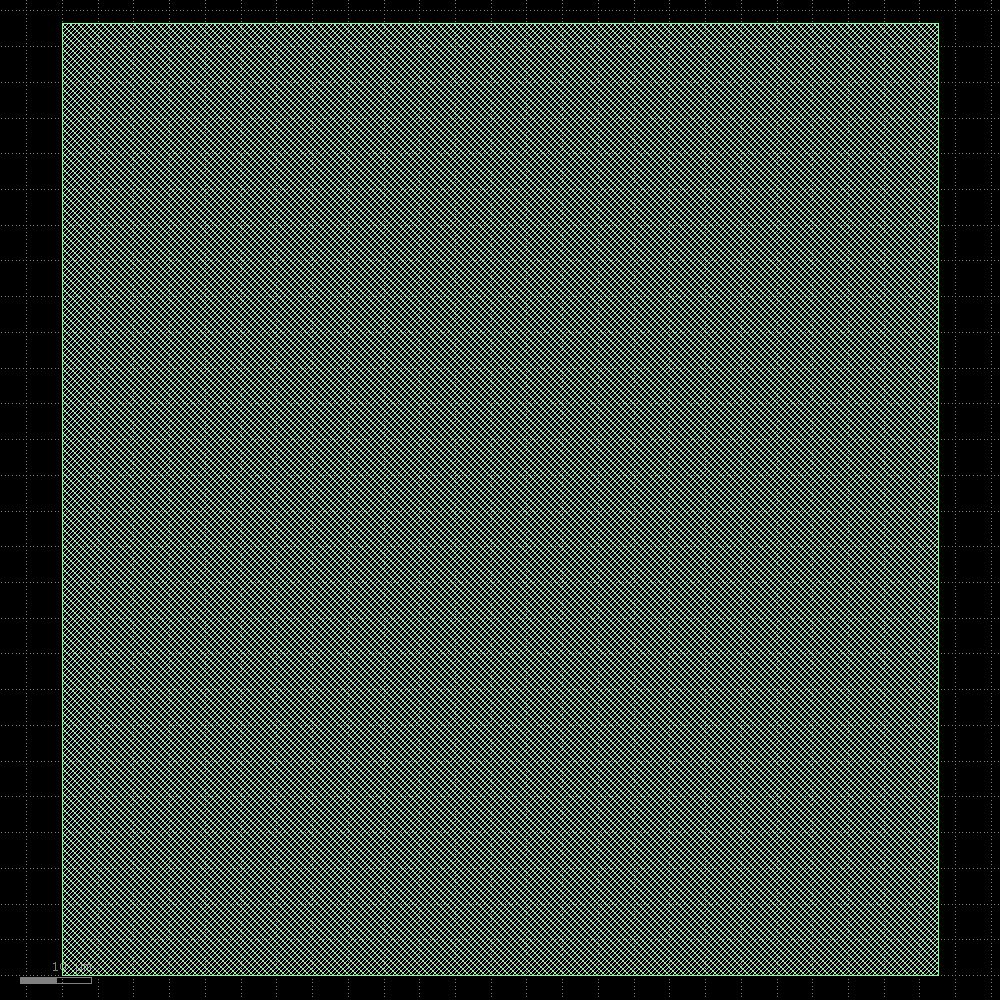

In [17]:
display(floorplan)

### Tap/Endcap Cell Insertion

This places two kinds of cells on the floorplan:

* End cap/boundary cells: Added at the beginning and end of each row. True to
  their name, they "cap off" the core area of a design.
* Tap cells: Placed in a polka dot-ish fashion across the rows. Tap cells
  connect VDD to the nwell and the psubstrate to VSS, which the majority of cells
  do not do themselves to save area- but if you go long enough without one such
  connection you end up with the cell "latching-up"; i.e.; refusing to switch
  back to LO from HI.

  There is a maximum distance between tap cells enforced as part of every
  foundry process.

In [18]:
TapEndcapInsertion = Step.factory.get("OpenROAD.TapEndcapInsertion")

tdi = TapEndcapInsertion(state_in=floorplan.state_out)
tdi.start()

─────────────────────────────────────────────── Tap/Decap Insertion ───────────────────────────────────────────────

[04:19:37] VERBOSE  Running 'OpenROAD.TapEndcapInsertion'…                                             ]8;id=448824;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=736345;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:19:37] VERBOSE  Logging subprocess to                                                              ]8;id=317367;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=346497;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\
                    ]8;id=114550;file:///content/openlane_run/4-openroad-tapendcapinsertion/openroad-tapendcapinsertion.log\openlane_run/]8;;\]8;id=925646;file:///content/openlane_run/4-openroad-tapendcapinsertion/openroad-tapendcapinsertion.log\4]8;;\]8;id=114550;file:///content/openlane_run/4-openroad-tapendcapinsertion/openroad-tapendcapinsertion.log\-openroad-tapendcapinsertion/openroad-tapendcapinsertion.log]8;;\…                    

Reading OpenROAD database at '/content/openlane_run/3-openroad-floorplan/riscv_core.odb'…

Reading library file at '/root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/openlane_run/4-openroad-tapendcapinsertion/riscv_core.nl.v'…

Writing powered netlist to '/content/openlane_run/4-openroad-tapendcapinsertion/riscv_core.pnl.v'…

Writing layout to '/content/openlane_run/4-openroad-tapendcapinsertion/riscv_core.def'…

Writing timing constraints to '/content/openlane_run/4-openroad-tapendcapinsertion/riscv_core.sdc'…

Format,Path
nl,openlane_run/4-openroad-tapendcapinsertion/riscv_core.nl.v
pnl,openlane_run/4-openroad-tapendcapinsertion/riscv_core.pnl.v
def,openlane_run/4-openroad-tapendcapinsertion/riscv_core.def
odb,openlane_run/4-openroad-tapendcapinsertion/riscv_core.odb
sdc,openlane_run/4-openroad-tapendcapinsertion/riscv_core.sdc


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[04:19:41] VERBOSE  Running 'KLayout.Render'…                                                          ]8;id=341402;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=604491;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:19:41] VERBOSE  Logging subprocess to ]8;id=520291;file:///tmp/openlane_klayout_tmp_0vcerlqq/klayout-render.log\..]8;;\]8;id=556594;file:///tmp/openlane_klayout_tmp_0vcerlqq/klayout-render.log\/tmp/openlane_klayout_tmp_0vcerlqq/]8;;\]8;id=511605;file:///tmp/openlane_klayout_tmp_0vcerlqq/klayout-render.log\klayout-render.log]8;;\…     ]8;id=364001;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=112300;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\

#### Time Elapsed: 0.61s
#### Views updated:
* Verilog Netlist
* Powered Verilog Netlist
* Design Exchange Format
* OpenDB Database
* Design Constraints
#### Preview:
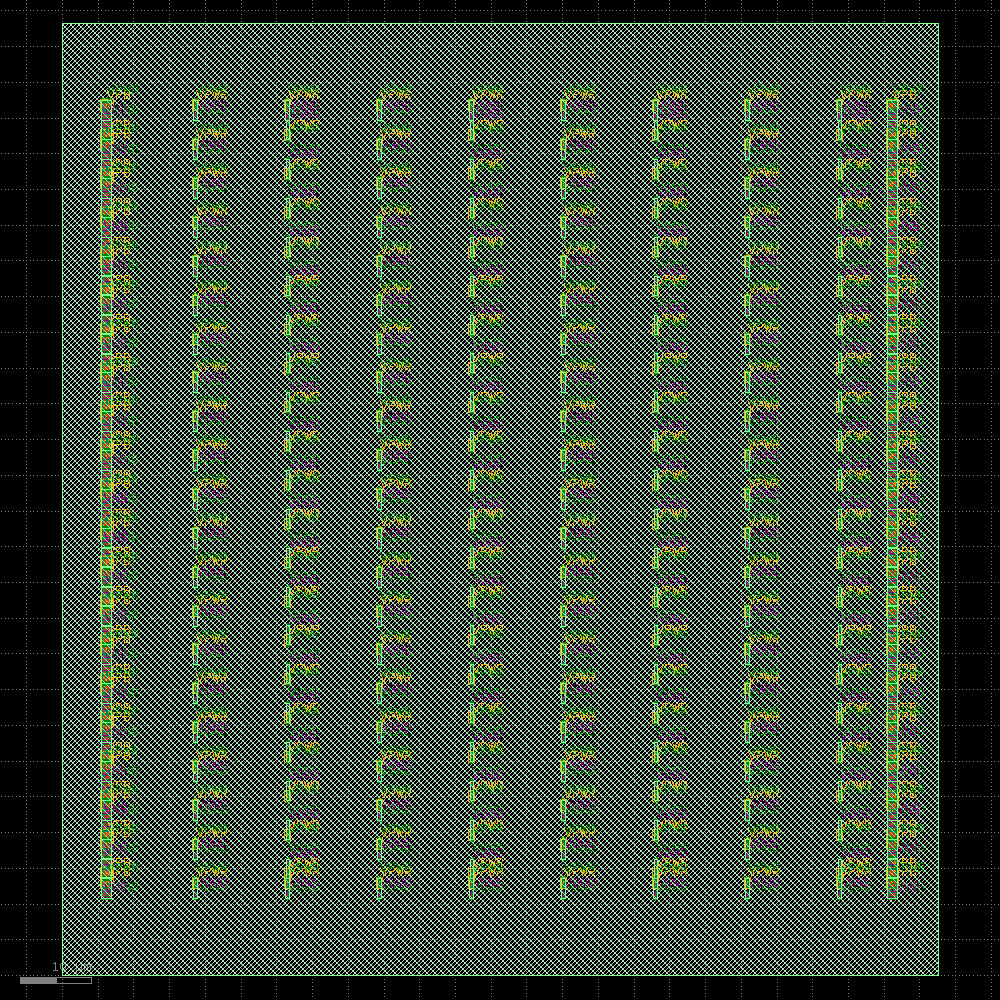

In [19]:
display(tdi)

### I/O Placement

This places metal pins at the edges of the design corresponding to the top level
inputs and outputs for your design. These pins act as the interface with other
designs when you integrate it with other designs.

In [20]:
IOPlacement = Step.factory.get("OpenROAD.IOPlacement")

ioplace = IOPlacement(state_in=tdi.state_out)
ioplace.start()

────────────────────────────────────────────────── I/O Placement ──────────────────────────────────────────────────

[04:19:52] VERBOSE  Running 'OpenROAD.IOPlacement'…                                                    ]8;id=176832;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=480345;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:19:52] VERBOSE  Logging subprocess to                                                              ]8;id=813058;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=221658;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\
                    ]8;id=378773;file:///content/openlane_run/5-openroad-ioplacement/openroad-ioplacement.log\openlane_run/]8;;\]8;id=172326;file:///content/openlane_run/5-openroad-ioplacement/openroad-ioplacement.log\5]8;;\]8;id=378773;file:///content/openlane_run/5-openroad-ioplacement/openroad-ioplacement.log\-openroad-ioplacement/openroad-ioplacement.log]8;;\…                                  

Reading OpenROAD database at '/content/openlane_run/4-openroad-tapendcapinsertion/riscv_core.odb'…

Reading library file at '/root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/openlane_run/5-openroad-ioplacement/riscv_core.nl.v'…

Writing powered netlist to '/content/openlane_run/5-openroad-ioplacement/riscv_core.pnl.v'…

Writing layout to '/content/openlane_run/5-openroad-ioplacement/riscv_core.def'…

Writing timing constraints to '/content/openlane_run/5-openroad-ioplacement/riscv_core.sdc'…

Format,Path
nl,openlane_run/5-openroad-ioplacement/riscv_core.nl.v
pnl,openlane_run/5-openroad-ioplacement/riscv_core.pnl.v
def,openlane_run/5-openroad-ioplacement/riscv_core.def
odb,openlane_run/5-openroad-ioplacement/riscv_core.odb
sdc,openlane_run/5-openroad-ioplacement/riscv_core.sdc


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[04:19:56] VERBOSE  Running 'KLayout.Render'…                                                          ]8;id=164666;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=619381;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:19:56] VERBOSE  Logging subprocess to ]8;id=599591;file:///tmp/openlane_klayout_tmp_p475ik13/klayout-render.log\..]8;;\]8;id=848874;file:///tmp/openlane_klayout_tmp_p475ik13/klayout-render.log\/tmp/openlane_klayout_tmp_p475ik13/]8;;\]8;id=586135;file:///tmp/openlane_klayout_tmp_p475ik13/klayout-render.log\klayout-render.log]8;;\…     ]8;id=549035;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=504116;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\

#### Time Elapsed: 0.61s
#### Views updated:
* Verilog Netlist
* Powered Verilog Netlist
* Design Exchange Format
* OpenDB Database
* Design Constraints
#### Preview:
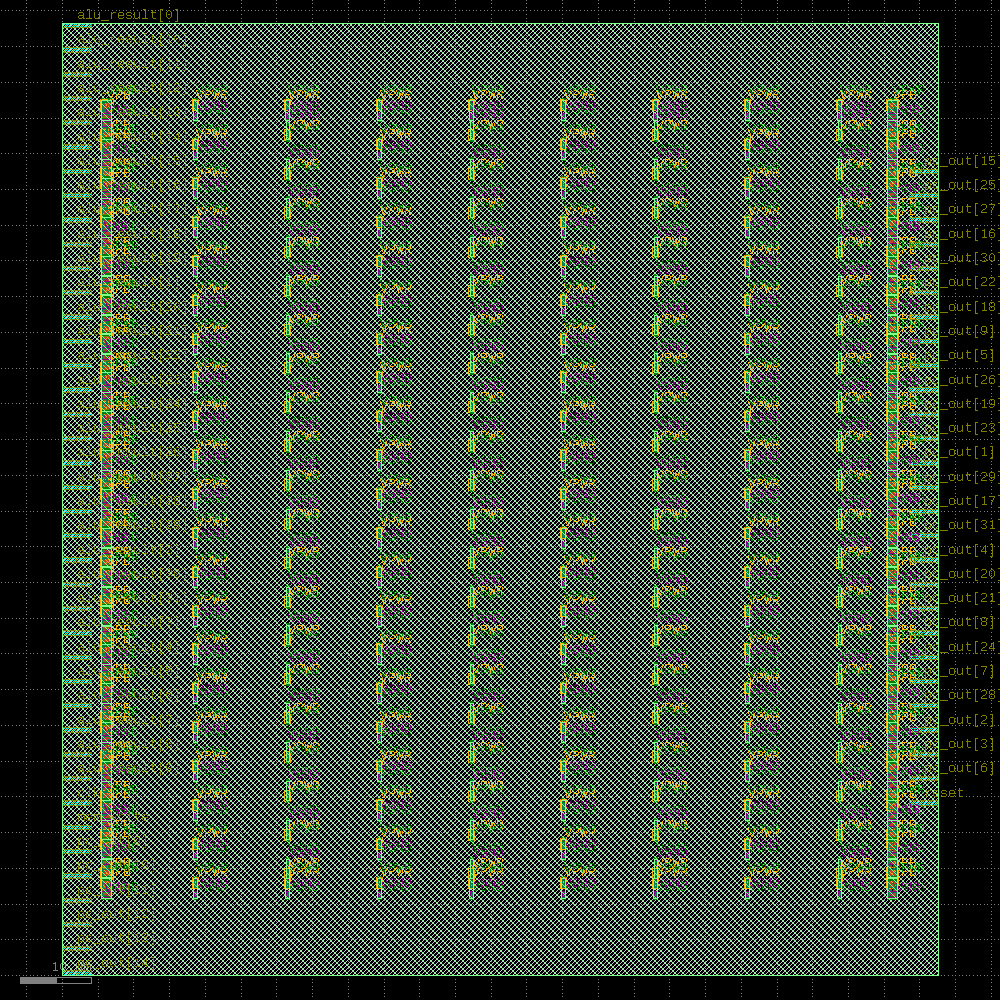

In [21]:
display(ioplace)

### Generating the Power Distribution Network (PDN)

This creates the power distribution network for your design, which is essentially
a plaid pattern of horizontal and vertical "straps" across the design that is
then connected to the rails' VDD and VSS (via the tap cells.)

You can find an explanation of how the power distribution network works at this
link: https://openlane2.readthedocs.io/en/latest/usage/hardening_macros.html#pdn-generation

While we typically don't need to mess with the PDN too much, the SPM is a small
design, so we're going to need to make the plaid pattern formed by the PDN a bit
smaller.

In [22]:
GeneratePDN = Step.factory.get("OpenROAD.GeneratePDN")

pdn = GeneratePDN(
    state_in=ioplace.state_out,
    FP_PDN_VWIDTH=2,
    FP_PDN_HWIDTH=2,
    FP_PDN_VPITCH=30,
    FP_PDN_HPITCH=30,
)
pdn.start()

────────────────────────────────────── Power Distribution Network Generation ──────────────────────────────────────

[04:20:04] VERBOSE  Running 'OpenROAD.GeneratePDN'…                                                    ]8;id=178913;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=564532;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:20:04] INFO     'FP_PDN_CFG' not explicitly set, setting it to                                 ]8;id=890265;file:///content/openlane_ipynb/openlane/steps/openroad.py\openroad.py]8;;\:]8;id=724633;file:///content/openlane_ipynb/openlane/steps/openroad.py#1174\1174]8;;\
                    /content/openlane_ipynb/openlane/scripts/openroad/common/pdn_cfg.tcl…                          

[04:20:04] VERBOSE  Logging subprocess to                                                              ]8;id=696290;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=419367;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\
                    ]8;id=972566;file:///content/openlane_run/6-openroad-generatepdn/openroad-generatepdn.log\openlane_run/]8;;\]8;id=763993;file:///content/openlane_run/6-openroad-generatepdn/openroad-generatepdn.log\6]8;;\]8;id=972566;file:///content/openlane_run/6-openroad-generatepdn/openroad-generatepdn.log\-openroad-generatepdn/openroad-generatepdn.log]8;;\…                                  

Reading OpenROAD database at '/content/openlane_run/5-openroad-ioplacement/riscv_core.odb'…

...

Writing layout to '/content/openlane_run/6-openroad-generatepdn/riscv_core.def'…

Writing timing constraints to '/content/openlane_run/6-openroad-generatepdn/riscv_core.sdc'…

[INFO PSM-0040] All shapes on net VPWR are connected.

[INFO PSM-0040] All shapes on net VGND are connected.

Format,Path
nl,openlane_run/6-openroad-generatepdn/riscv_core.nl.v
pnl,openlane_run/6-openroad-generatepdn/riscv_core.pnl.v
def,openlane_run/6-openroad-generatepdn/riscv_core.def
odb,openlane_run/6-openroad-generatepdn/riscv_core.odb
sdc,openlane_run/6-openroad-generatepdn/riscv_core.sdc


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[04:20:08] VERBOSE  Running 'KLayout.Render'…                                                          ]8;id=871556;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=338613;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:20:08] VERBOSE  Logging subprocess to ]8;id=767155;file:///tmp/openlane_klayout_tmp_ax6bsrp5/klayout-render.log\..]8;;\]8;id=537646;file:///tmp/openlane_klayout_tmp_ax6bsrp5/klayout-render.log\/tmp/openlane_klayout_tmp_ax6bsrp5/]8;;\]8;id=113562;file:///tmp/openlane_klayout_tmp_ax6bsrp5/klayout-render.log\klayout-render.log]8;;\…     ]8;id=756725;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=68380;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\

#### Time Elapsed: 0.71s
#### Views updated:
* Verilog Netlist
* Powered Verilog Netlist
* Design Exchange Format
* OpenDB Database
* Design Constraints
#### Preview:
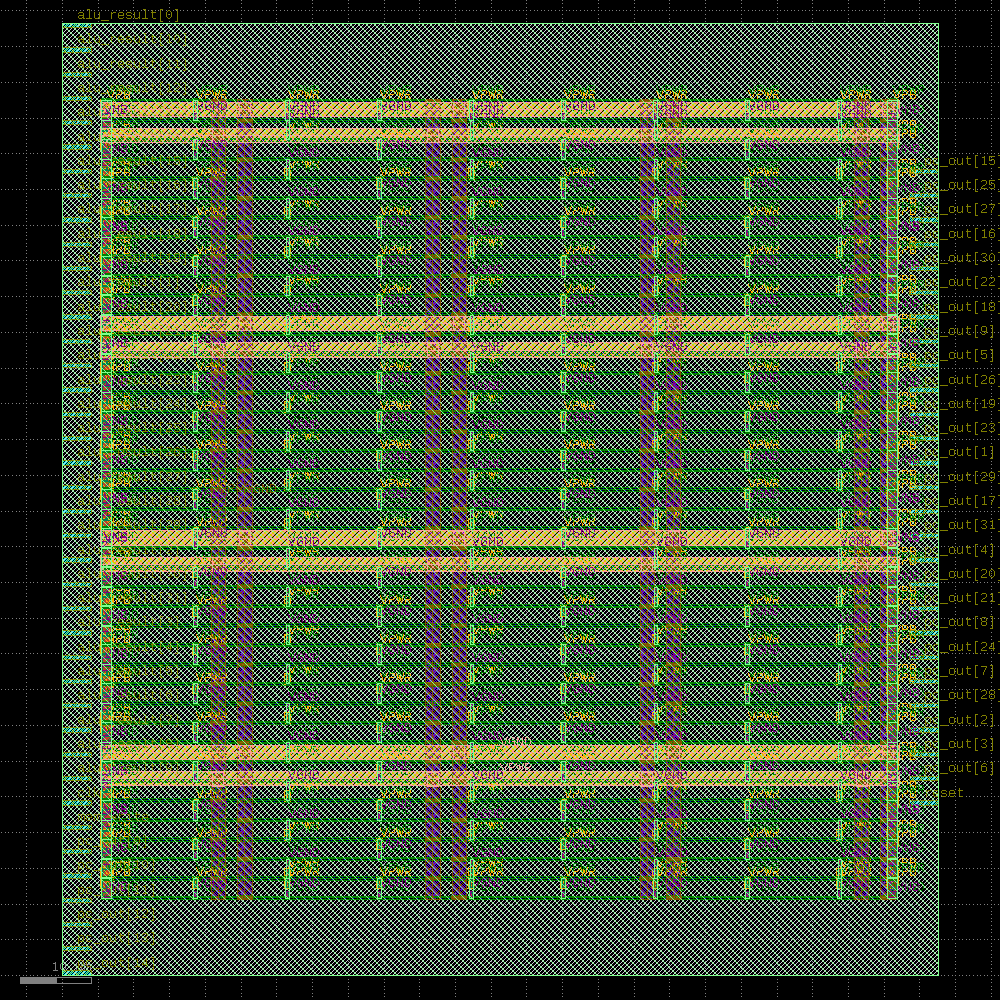

In [23]:
display(pdn)

### Global Placement

Global Placement is deciding on a fuzzy, non-final location for each of the cells,
with the aim of minimizing the distance between cells that are connected
together (more specifically, the total length of the not-yet-created wires that
will connect them).

As you will see in the `.display()` in the second cell below, the placement is
considered "illegal", i.e., not properly aligned with the cell placement grid.
This is addressed by "Detailed Placement", also referred to as "placement
legalization", which is the next step.

In [24]:
GlobalPlacement = Step.factory.get("OpenROAD.GlobalPlacement")

gpl = GlobalPlacement(state_in=pdn.state_out)
gpl.start()

──────────────────────────────────────────────── Global Placement ─────────────────────────────────────────────────

[04:20:16] VERBOSE  Running 'OpenROAD.GlobalPlacement'…                                                ]8;id=742360;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=868766;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:20:16] INFO     'PL_TARGET_DENSITY_PCT' not explicitly set, using dynamically calculated       ]8;id=92695;file:///content/openlane_ipynb/openlane/steps/openroad.py\openroad.py]8;;\:]8;id=364889;file:///content/openlane_ipynb/openlane/steps/openroad.py#1260\1260]8;;\
                    target density: 61.834300…                                                                     

[04:20:16] VERBOSE  Logging subprocess to                                                              ]8;id=680910;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=465323;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\
                    ]8;id=758355;file:///content/openlane_run/7-openroad-globalplacement/openroad-globalplacement.log\openlane_run/]8;;\]8;id=681832;file:///content/openlane_run/7-openroad-globalplacement/openroad-globalplacement.log\7]8;;\]8;id=758355;file:///content/openlane_run/7-openroad-globalplacement/openroad-globalplacement.log\-openroad-globalplacement/openroad-globalplacement.log]8;;\…                          

Reading OpenROAD database at '/content/openlane_run/6-openroad-generatepdn/riscv_core.odb'…

...

Writing netlist to '/content/openlane_run/7-openroad-globalplacement/riscv_core.nl.v'…

Writing powered netlist to '/content/openlane_run/7-openroad-globalplacement/riscv_core.pnl.v'…

Writing layout to '/content/openlane_run/7-openroad-globalplacement/riscv_core.def'…

Writing timing constraints to '/content/openlane_run/7-openroad-globalplacement/riscv_core.sdc'…

Format,Path
nl,openlane_run/7-openroad-globalplacement/riscv_core.nl.v
pnl,openlane_run/7-openroad-globalplacement/riscv_core.pnl.v
def,openlane_run/7-openroad-globalplacement/riscv_core.def
odb,openlane_run/7-openroad-globalplacement/riscv_core.odb
sdc,openlane_run/7-openroad-globalplacement/riscv_core.sdc


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[04:20:22] VERBOSE  Running 'KLayout.Render'…                                                          ]8;id=604475;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=180996;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:20:22] VERBOSE  Logging subprocess to ]8;id=59971;file:///tmp/openlane_klayout_tmp_pqpxchnd/klayout-render.log\..]8;;\]8;id=176715;file:///tmp/openlane_klayout_tmp_pqpxchnd/klayout-render.log\/tmp/openlane_klayout_tmp_pqpxchnd/]8;;\]8;id=827397;file:///tmp/openlane_klayout_tmp_pqpxchnd/klayout-render.log\klayout-render.log]8;;\…     ]8;id=838613;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=38484;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\

#### Time Elapsed: 2.24s
#### Views updated:
* Verilog Netlist
* Powered Verilog Netlist
* Design Exchange Format
* OpenDB Database
* Design Constraints
#### Preview:
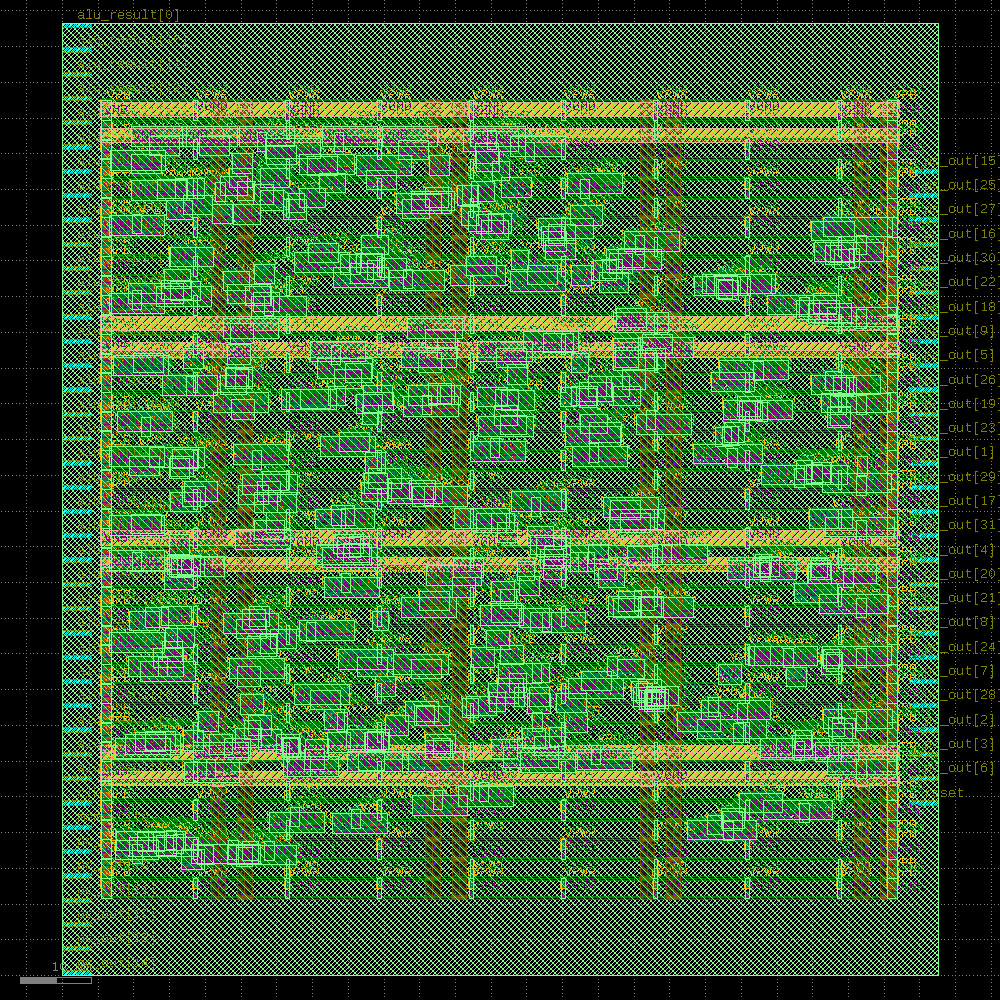

In [25]:
display(gpl)

### Detailed Placement

This aligns the fuzzy placement from before with the grid, "legalizing" it.

In [26]:
DetailedPlacement = Step.factory.get("OpenROAD.DetailedPlacement")

dpl = DetailedPlacement(state_in=gpl.state_out)
dpl.start()

─────────────────────────────────────────────── Detailed Placement ────────────────────────────────────────────────

[04:20:29] VERBOSE  Running 'OpenROAD.DetailedPlacement'…                                              ]8;id=456773;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=458754;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:20:29] VERBOSE  Logging subprocess to                                                              ]8;id=896567;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=40821;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\
                    ]8;id=752914;file:///content/openlane_run/8-openroad-detailedplacement/openroad-detailedplacement.log\openlane_run/]8;;\]8;id=555501;file:///content/openlane_run/8-openroad-detailedplacement/openroad-detailedplacement.log\8]8;;\]8;id=752914;file:///content/openlane_run/8-openroad-detailedplacement/openroad-detailedplacement.log\-openroad-detailedplacement/openroad-detailedplacement.log]8;;\…                      

Reading OpenROAD database at '/content/openlane_run/7-openroad-globalplacement/riscv_core.odb'…

Reading library file at '/root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/openlane_run/8-openroad-detailedplacement/riscv_core.nl.v'…

Writing powered netlist to '/content/openlane_run/8-openroad-detailedplacement/riscv_core.pnl.v'…

Writing layout to '/content/openlane_run/8-openroad-detailedplacement/riscv_core.def'…

Writing timing constraints to '/content/openlane_run/8-openroad-detailedplacement/riscv_core.sdc'…

Format,Path
nl,openlane_run/8-openroad-detailedplacement/riscv_core.nl.v
pnl,openlane_run/8-openroad-detailedplacement/riscv_core.pnl.v
def,openlane_run/8-openroad-detailedplacement/riscv_core.def
odb,openlane_run/8-openroad-detailedplacement/riscv_core.odb
sdc,openlane_run/8-openroad-detailedplacement/riscv_core.sdc


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[04:20:34] VERBOSE  Running 'KLayout.Render'…                                                          ]8;id=418828;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=741351;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:20:34] VERBOSE  Logging subprocess to ]8;id=586760;file:///tmp/openlane_klayout_tmp_45n7y4t3/klayout-render.log\..]8;;\]8;id=971967;file:///tmp/openlane_klayout_tmp_45n7y4t3/klayout-render.log\/tmp/openlane_klayout_tmp_45n7y4t3/]8;;\]8;id=783789;file:///tmp/openlane_klayout_tmp_45n7y4t3/klayout-render.log\klayout-render.log]8;;\…     ]8;id=971972;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=661339;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\

#### Time Elapsed: 0.71s
#### Views updated:
* Verilog Netlist
* Powered Verilog Netlist
* Design Exchange Format
* OpenDB Database
* Design Constraints
#### Preview:
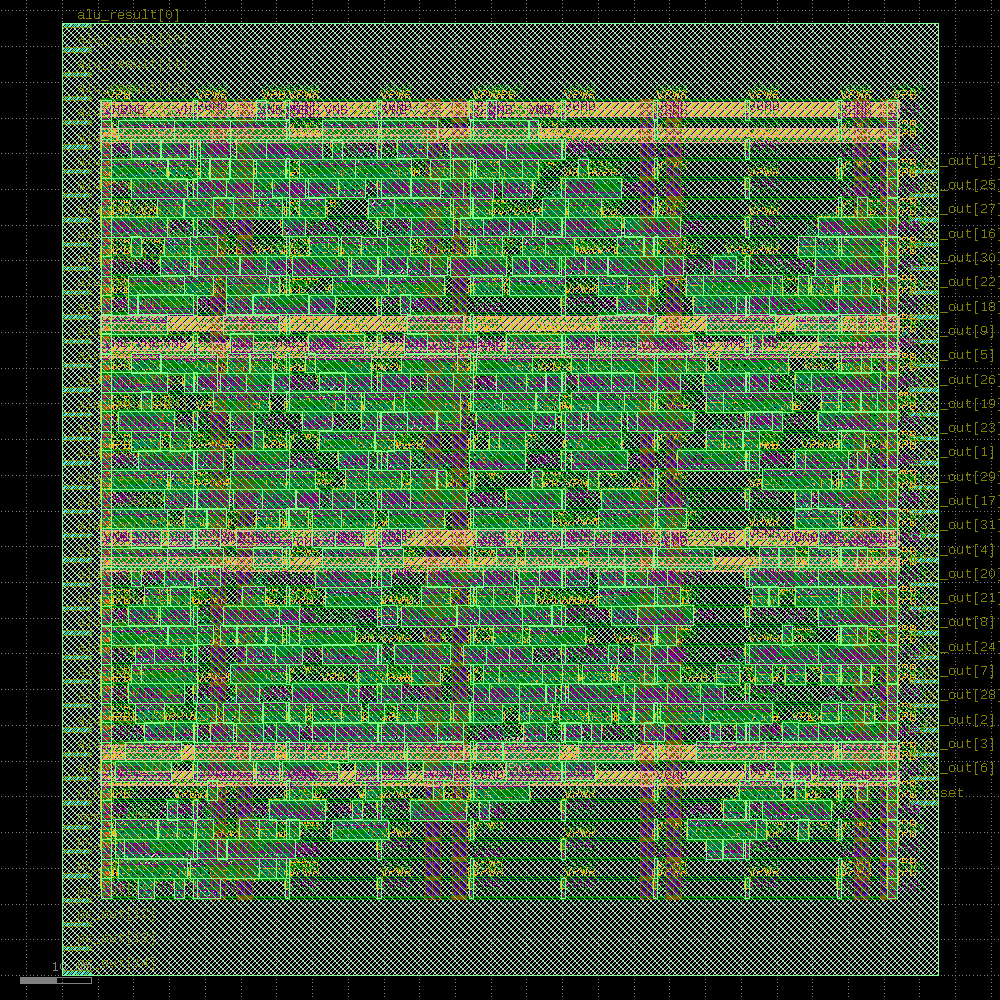

In [27]:
display(dpl)

### Clock Tree Synthesis (CTS)

With the cells now having a final placement, we can go ahead and create what
is known as the clock tree, i.e., the hierarchical set of buffers used
for clock signal to minimize what is known as "clock skew"- variable delay
of the clock cycle from register to register because of factors such as metal
wire length, clock load (number of gates connected to the same clock buffer,)
et cetera.

The CTS step creates the cells and places the between the gaps in the detailed
placement above.

In [28]:
CTS = Step.factory.get("OpenROAD.CTS")

cts = CTS(state_in=dpl.state_out)
cts.start()

────────────────────────────────────────────── Clock Tree Synthesis ───────────────────────────────────────────────

[04:20:44] VERBOSE  Running 'OpenROAD.CTS'…                                                            ]8;id=264344;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=521427;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:20:44] VERBOSE  Logging subprocess to ]8;id=63603;file:///content/openlane_run/9-openroad-cts/openroad-cts.log\openlane_run/]8;;\]8;id=369945;file:///content/openlane_run/9-openroad-cts/openroad-cts.log\9]8;;\]8;id=63603;file:///content/openlane_run/9-openroad-cts/openroad-cts.log\-openroad-cts/openroad-cts.log]8;;\…                ]8;id=454793;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=61012;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\

Reading timing models for corner nom_tt_025C_1v80…

Reading timing library for the 'nom_tt_025C_1v80' corner at                                                        
'/root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/openlane_run/9-openroad-cts/riscv_core.nl.v'…

Writing powered netlist to '/content/openlane_run/9-openroad-cts/riscv_core.pnl.v'…

Writing layout to '/content/openlane_run/9-openroad-cts/riscv_core.def'…

Writing timing constraints to '/content/openlane_run/9-openroad-cts/riscv_core.sdc'…

Format,Path
nl,openlane_run/9-openroad-cts/riscv_core.nl.v
pnl,openlane_run/9-openroad-cts/riscv_core.pnl.v
def,openlane_run/9-openroad-cts/riscv_core.def
odb,openlane_run/9-openroad-cts/riscv_core.odb
sdc,openlane_run/9-openroad-cts/riscv_core.sdc


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[04:20:56] VERBOSE  Running 'KLayout.Render'…                                                          ]8;id=69985;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=809032;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:20:56] VERBOSE  Logging subprocess to ]8;id=266505;file:///tmp/openlane_klayout_tmp_x6le4txg/klayout-render.log\..]8;;\]8;id=378808;file:///tmp/openlane_klayout_tmp_x6le4txg/klayout-render.log\/tmp/openlane_klayout_tmp_x6le4txg/]8;;\]8;id=223344;file:///tmp/openlane_klayout_tmp_x6le4txg/klayout-render.log\klayout-render.log]8;;\…     ]8;id=625628;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=991284;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\

#### Time Elapsed: 8.45s
#### Views updated:
* Verilog Netlist
* Powered Verilog Netlist
* Design Exchange Format
* OpenDB Database
* Design Constraints
#### Preview:
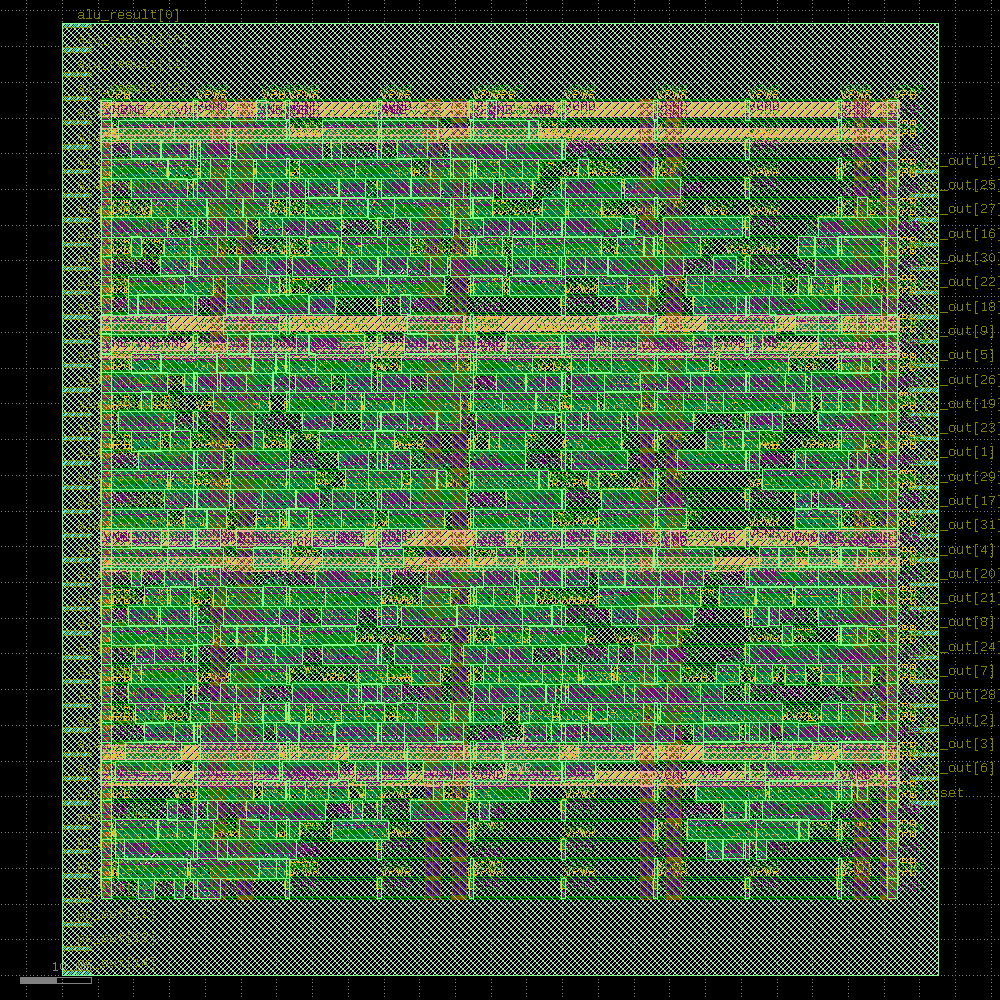

In [29]:
display(cts)

### Global Routing

Global routing "plans" the routes the wires between two gates (or gates and
I/O pins/the PDN) will take. The results of global routing (which are called
"routing guides") are stored in internal data structures and have no effect on
the actual design, so there is no `display()` statement.

In [30]:
GlobalRouting = Step.factory.get("OpenROAD.GlobalRouting")

grt = GlobalRouting(state_in=cts.state_out)
grt.start()

───────────────────────────────────────────────── Global Routing ──────────────────────────────────────────────────

[04:21:05] VERBOSE  Running 'OpenROAD.GlobalRouting'…                                                  ]8;id=131974;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=551556;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:21:05] VERBOSE  Logging subprocess to                                                              ]8;id=372574;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=509163;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\
                    ]8;id=871404;file:///content/openlane_run/10-openroad-globalrouting/openroad-globalrouting.log\openlane_run/]8;;\]8;id=183754;file:///content/openlane_run/10-openroad-globalrouting/openroad-globalrouting.log\10]8;;\]8;id=871404;file:///content/openlane_run/10-openroad-globalrouting/openroad-globalrouting.log\-openroad-globalrouting/openroad-globalrouting.log]8;;\…                             

Reading OpenROAD database at '/content/openlane_run/9-openroad-cts/riscv_core.odb'…

Reading library file at '/root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Setting global connections for newly added cells…

[INFO] Setting global connections...

Writing OpenROAD database to '/content/openlane_run/10-openroad-globalrouting/riscv_core.odb'…

Writing layout to '/content/openlane_run/10-openroad-globalrouting/riscv_core.def'…

Format,Path
nl,openlane_run/9-openroad-cts/riscv_core.nl.v
pnl,openlane_run/9-openroad-cts/riscv_core.pnl.v
def,openlane_run/10-openroad-globalrouting/riscv_core.def
odb,openlane_run/10-openroad-globalrouting/riscv_core.odb
sdc,openlane_run/9-openroad-cts/riscv_core.sdc


### Detailed Routing

Detailed routing uses the guides from Global Routing to actually create wires
on the metal layers and connect the gates, making the connections finally physical.

This is typically the longest step in the flow.

In [31]:
DetailedRouting = Step.factory.get("OpenROAD.DetailedRouting")

drt = DetailedRouting(state_in=grt.state_out)
drt.start()

──────────────────────────────────────────────── Detailed Routing ─────────────────────────────────────────────────

[04:21:39] VERBOSE  Running 'OpenROAD.DetailedRouting'…                                                ]8;id=492635;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=780394;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:21:39] INFO     Running TritonRoute with 96 threads…                                           ]8;id=655734;file:///content/openlane_ipynb/openlane/steps/openroad.py\openroad.py]8;;\:]8;id=190282;file:///content/openlane_ipynb/openlane/steps/openroad.py#1619\1619]8;;\

[04:21:39] VERBOSE  Logging subprocess to                                                              ]8;id=290599;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=349632;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\
                    ]8;id=141862;file:///content/openlane_run/11-openroad-detailedrouting/openroad-detailedrouting.log\openlane_run/]8;;\]8;id=698029;file:///content/openlane_run/11-openroad-detailedrouting/openroad-detailedrouting.log\11]8;;\]8;id=141862;file:///content/openlane_run/11-openroad-detailedrouting/openroad-detailedrouting.log\-openroad-detailedrouting/openroad-detailedrouting.log]8;;\…                         

Reading OpenROAD database at '/content/openlane_run/10-openroad-globalrouting/riscv_core.odb'…

...

Writing netlist to '/content/openlane_run/11-openroad-detailedrouting/riscv_core.nl.v'…

Writing powered netlist to '/content/openlane_run/11-openroad-detailedrouting/riscv_core.pnl.v'…

Writing layout to '/content/openlane_run/11-openroad-detailedrouting/riscv_core.def'…

Writing timing constraints to '/content/openlane_run/11-openroad-detailedrouting/riscv_core.sdc'…

Format,Path
nl,openlane_run/11-openroad-detailedrouting/riscv_core.nl.v
pnl,openlane_run/11-openroad-detailedrouting/riscv_core.pnl.v
def,openlane_run/11-openroad-detailedrouting/riscv_core.def
odb,openlane_run/11-openroad-detailedrouting/riscv_core.odb
sdc,openlane_run/11-openroad-detailedrouting/riscv_core.sdc


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[04:22:13] VERBOSE  Running 'KLayout.Render'…                                                          ]8;id=67054;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=195518;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:22:13] VERBOSE  Logging subprocess to ]8;id=113017;file:///tmp/openlane_klayout_tmp_fu9mcomx/klayout-render.log\..]8;;\]8;id=391225;file:///tmp/openlane_klayout_tmp_fu9mcomx/klayout-render.log\/tmp/openlane_klayout_tmp_fu9mcomx/]8;;\]8;id=978839;file:///tmp/openlane_klayout_tmp_fu9mcomx/klayout-render.log\klayout-render.log]8;;\…     ]8;id=873859;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=686470;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\

#### Time Elapsed: 24.65s
#### Views updated:
* Verilog Netlist
* Powered Verilog Netlist
* Design Exchange Format
* OpenDB Database
* Design Constraints
#### Preview:
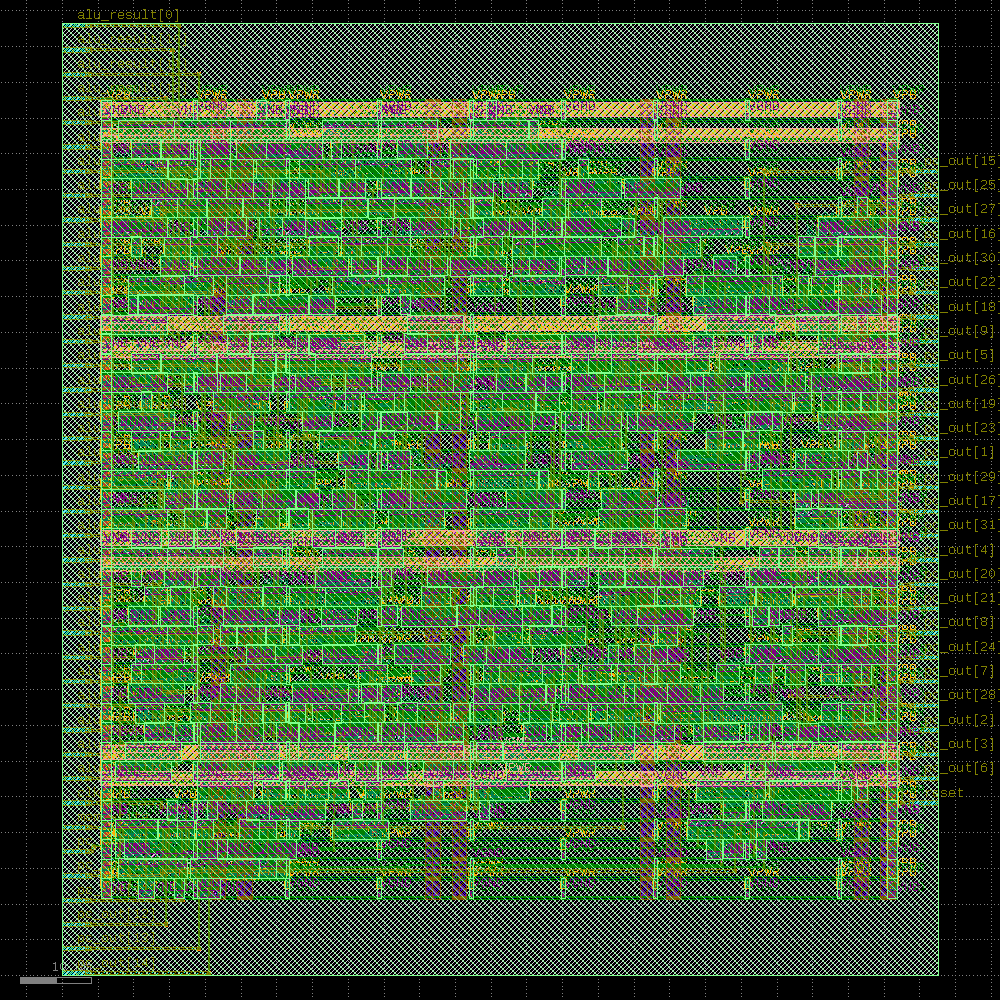

In [32]:
display(drt)

### Fill Insertion

Finally, as we're done placing all the essential cells, the only thing left to
do is fill in the gaps.

We prioritize the use of decap (decoupling capacitor) cells, which
further supports the power distribution network, but when there aren't any
small enough cells, we just use regular fill cells.

In [33]:
FillInsertion = Step.factory.get("OpenROAD.FillInsertion")

fill = FillInsertion(state_in=drt.state_out)
fill.start()

───────────────────────────────────────────────── Fill Insertion ──────────────────────────────────────────────────

[04:22:22] VERBOSE  Running 'OpenROAD.FillInsertion'…                                                  ]8;id=430234;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=736957;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:22:22] VERBOSE  Logging subprocess to                                                              ]8;id=44475;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=314439;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\
                    ]8;id=781308;file:///content/openlane_run/12-openroad-fillinsertion/openroad-fillinsertion.log\openlane_run/]8;;\]8;id=809678;file:///content/openlane_run/12-openroad-fillinsertion/openroad-fillinsertion.log\12]8;;\]8;id=781308;file:///content/openlane_run/12-openroad-fillinsertion/openroad-fillinsertion.log\-openroad-fillinsertion/openroad-fillinsertion.log]8;;\…                             

Reading OpenROAD database at '/content/openlane_run/11-openroad-detailedrouting/riscv_core.odb'…

Reading library file at '/root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing netlist to '/content/openlane_run/12-openroad-fillinsertion/riscv_core.nl.v'…

Writing powered netlist to '/content/openlane_run/12-openroad-fillinsertion/riscv_core.pnl.v'…

Writing layout to '/content/openlane_run/12-openroad-fillinsertion/riscv_core.def'…

Writing timing constraints to '/content/openlane_run/12-openroad-fillinsertion/riscv_core.sdc'…

Format,Path
nl,openlane_run/12-openroad-fillinsertion/riscv_core.nl.v
pnl,openlane_run/12-openroad-fillinsertion/riscv_core.pnl.v
def,openlane_run/12-openroad-fillinsertion/riscv_core.def
odb,openlane_run/12-openroad-fillinsertion/riscv_core.odb
sdc,openlane_run/12-openroad-fillinsertion/riscv_core.sdc


──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[04:22:27] VERBOSE  Running 'KLayout.Render'…                                                          ]8;id=841144;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=176297;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:22:27] VERBOSE  Logging subprocess to ]8;id=545697;file:///tmp/openlane_klayout_tmp_lobk3w3t/klayout-render.log\..]8;;\]8;id=152839;file:///tmp/openlane_klayout_tmp_lobk3w3t/klayout-render.log\/tmp/openlane_klayout_tmp_lobk3w3t/]8;;\]8;id=703865;file:///tmp/openlane_klayout_tmp_lobk3w3t/klayout-render.log\klayout-render.log]8;;\…     ]8;id=546130;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=85740;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\

#### Time Elapsed: 0.71s
#### Views updated:
* Verilog Netlist
* Powered Verilog Netlist
* Design Exchange Format
* OpenDB Database
* Design Constraints
#### Preview:
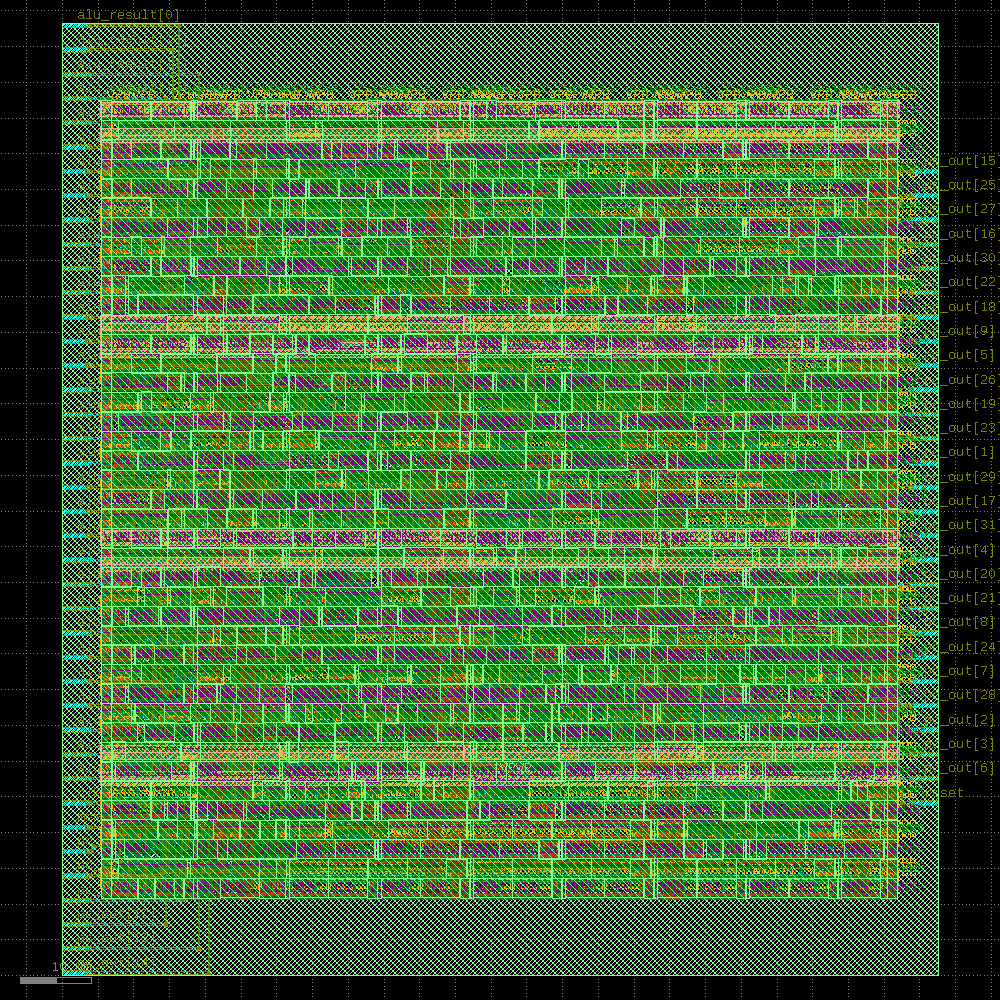

In [34]:
display(fill)

### Parasitics Extraction a.k.a. Resistance/Capacitance Extraction (RCX)

This step does not alter the design- rather, it computes the
[Parasitic elements](https://en.wikipedia.org/wiki/Parasitic_element_(electrical_networks))
of the circuit, which have an effect of timing, as we prepare to do the final
timing analysis.

The parasitic elements are saved in the **Standard Parasitics Exchange Format**,
or SPEF. OpenLane creates a SPEF file for each interconnect corner as described in
the [Corners and STA](https://openlane2.readthedocs.io/en/latest/usage/corners_and_sta.html)
section of the documentation.

In [35]:
RCX = Step.factory.get("OpenROAD.RCX")

rcx = RCX(state_in=fill.state_out)
rcx.start()

─────────────────────────────────── Parasitic Resistance/Capacitance Extraction ───────────────────────────────────

[04:22:35] VERBOSE  Running 'OpenROAD.RCX'…                                                            ]8;id=330390;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=339979;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:22:35] INFO     Running RCX for corners matching nom_*                                         ]8;id=994000;file:///content/openlane_ipynb/openlane/steps/openroad.py\openroad.py]8;;\:]8;id=795385;file:///content/openlane_ipynb/openlane/steps/openroad.py#1748\1748]8;;\
                    (/content/openlane_run/13-openroad-rcx/nom/rcx.log)…                                           

[04:22:35] INFO     Running RCX for corners matching min_*                                         ]8;id=996659;file:///content/openlane_ipynb/openlane/steps/openroad.py\openroad.py]8;;\:]8;id=373299;file:///content/openlane_ipynb/openlane/steps/openroad.py#1748\1748]8;;\
                    (/content/openlane_run/13-openroad-rcx/min/rcx.log)…                                           

[04:22:35] INFO     Running RCX for corners matching max_*                                         ]8;id=71969;file:///content/openlane_ipynb/openlane/steps/openroad.py\openroad.py]8;;\:]8;id=421626;file:///content/openlane_ipynb/openlane/steps/openroad.py#1748\1748]8;;\
                    (/content/openlane_run/13-openroad-rcx/max/rcx.log)…                                           

...

[04:22:35] VERBOSE  Logging subprocess to ]8;id=507800;file:///content/openlane_run/13-openroad-rcx/max/rcx.log\openlane_run/]8;;\]8;id=60615;file:///content/openlane_run/13-openroad-rcx/max/rcx.log\13]8;;\]8;id=507800;file:///content/openlane_run/13-openroad-rcx/max/rcx.log\-openroad-rcx/max/rcx.log]8;;\…                    ]8;id=75243;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=106689;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\

[04:22:36] INFO     Finished RCX for corners matching nom_*.                                       ]8;id=168363;file:///content/openlane_ipynb/openlane/steps/openroad.py\openroad.py]8;;\:]8;id=704311;file:///content/openlane_ipynb/openlane/steps/openroad.py#1757\1757]8;;\

[04:22:36] INFO     Finished RCX for corners matching min_*.                                       ]8;id=736861;file:///content/openlane_ipynb/openlane/steps/openroad.py\openroad.py]8;;\:]8;id=6449;file:///content/openlane_ipynb/openlane/steps/openroad.py#1757\1757]8;;\

[04:22:36] INFO     Finished RCX for corners matching max_*.                                       ]8;id=65173;file:///content/openlane_ipynb/openlane/steps/openroad.py\openroad.py]8;;\:]8;id=82419;file:///content/openlane_ipynb/openlane/steps/openroad.py#1757\1757]8;;\

{'nl': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.nl.v'), 'pnl': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.pnl.v'), 'pnl-sdf-friendly': None, 'pnl-npc': None, 'def': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.def'), 'lef': None, 'openroad-lef': None, 'odb': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.odb'), 'sdc': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.sdc'), 'sdf': None, 'spef': {'nom_*': Path('/content/openlane_run/13-openroad-rcx/nom/riscv_core.nom.spef'), 'min_*': Path('/content/openlane_run/13-openroad-rcx/min/riscv_core.min.spef'), 'max_*': Path('/content/openlane_run/13-openroad-rcx/max/riscv_core.max.spef')}, 'lib': None, 'spice': None, 'mag': None, 'gds': None, 'mag_gds': None, 'klayout_gds': None, 'json_h': None, 'vh': None, 'metrics': {'design__instance__count': 736, 'design__instance__area': Decimal('6882.85'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 122.57 133.29', 'design__core__bbox': '5.52 10.88 116.84 122.4', 'flow__warnings__count': 0, 'flow__errors__count': 0, 'design__io': 69, 'design__die__area': Decimal('16337.4'), 'design__core__area': Decimal('12414.4'), 'design__instance__count__stdcell': 736, 'design__instance__area__stdcell': Decimal('6882.85'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__utilization': Decimal('0.554425'), 'design__instance__utilization__stdcell': Decimal('0.554425'), 'floorplan__design__io': 67, 'design__io__hpwl': 6086590, 'design__power_grid_violation__count__net:VGND': 0, 'design__power_grid_violation__count__net:VPWR': 0, 'design__power_grid_violation__count': 0, 'design__instance__displacement__total': Decimal('326.599'), 'design__instance__displacement__mean': Decimal('0.399'), 'design__instance__displacement__max': Decimal('9.62'), 'route__wirelength__estimated': Decimal('10264.6'), 'design__violations': 0, 'antenna__violating__nets': 0, 'antenna__violating__pins': 0, 'route__net': 551, 'route__net__special': 2, 'route__drc_errors__iter:1': 329, 'route__wirelength__iter:1': 12791, 'route__drc_errors__iter:2': 33, 'route__wirelength__iter:2': 12731, 'route__drc_errors__iter:3': 22, 'route__wirelength__iter:3': 12712, 'route__drc_errors__iter:4': 0, 'route__wirelength__iter:4': 12710, 'route__drc_errors': 0, 'route__wirelength': 12710, 'route__vias': 3849, 'route__vias__singlecut': 3849, 'route__vias__multicut': 0}}

### Static Timing Analysis (Post-PnR)

STA is a process that verifies that a chip meets certain constraints on clock
and data timings to run at its rated clock speed. See [Corners and STA](https://openlane2.readthedocs.io/en/latest/usage/corners_and_sta.html)
in the documentation for more info.

---

This step generates two kinds of files:
* `.lib`: Liberty™-compatible Library files. Can be used to do static timing
  analysis when creating a design with this design as a sub-macro.
* `.sdf`: Standard Delay Format. Can be used with certain simulation software
  to do *dynamic* timing analysis.

Unfortunately, the `.lib` files coming out of OpenLane right now are not super
reliable for timing purposes and are only provided for completeness.
When using OpenLane-created macros withing other designs, it is best to use the
macro's final netlist and extracted parasitics instead.

In [36]:
STAPostPNR = Step.factory.get("OpenROAD.STAPostPNR")

sta_post_pnr = STAPostPNR(state_in=rcx.state_out)
sta_post_pnr.start()

──────────────────────────────────────── Static Timing Analysis (Post-PnR) ────────────────────────────────────────

[04:22:41] VERBOSE  Running 'OpenROAD.STAPostPNR'…                                                     ]8;id=654646;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=623307;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:22:41] INFO     Starting STA for the nom_tt_025C_1v80 timing corner…                            ]8;id=67255;file:///content/openlane_ipynb/openlane/steps/openroad.py\openroad.py]8;;\:]8;id=172481;file:///content/openlane_ipynb/openlane/steps/openroad.py#561\561]8;;\

[04:22:41] INFO     Starting STA for the nom_ss_100C_1v60 timing corner…                            ]8;id=456085;file:///content/openlane_ipynb/openlane/steps/openroad.py\openroad.py]8;;\:]8;id=628841;file:///content/openlane_ipynb/openlane/steps/openroad.py#561\561]8;;\

[04:22:41] INFO     Starting STA for the nom_ff_n40C_1v95 timing corner…                            ]8;id=827822;file:///content/openlane_ipynb/openlane/steps/openroad.py\openroad.py]8;;\:]8;id=127621;file:///content/openlane_ipynb/openlane/steps/openroad.py#561\561]8;;\

...

[04:22:43] VERBOSE  Logging subprocess to                                                              ]8;id=292166;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=843645;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\
                    ]8;id=909492;file:///content/openlane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/filter_unannotated.log\openlane_run/]8;;\]8;id=408744;file:///content/openlane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/filter_unannotated.log\14]8;;\]8;id=909492;file:///content/openlane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/filter_unannotated.log\-openroad-stapostpnr/nom_ff_n40C_1v95/filter_unannotated.log]8;;\…                   

[04:22:43] VERBOSE  Logging subprocess to                                                              ]8;id=875420;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=207972;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\
                    ]8;id=821348;file:///content/openlane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/filter_unannotated.log\openlane_run/]8;;\]8;id=76252;file:///content/openlane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/filter_unannotated.log\14]8;;\]8;id=821348;file:///content/openlane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/filter_unannotated.log\-openroad-stapostpnr/max_ff_n40C_1v95/filter_unannotated.log]8;;\…                   

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━┓
┃                      ┃       ┃       ┃      ┃       ┃ of   ┃       ┃      ┃       ┃      ┃ of    ┃      ┃       ┃
┃                      ┃       ┃ Reg   ┃      ┃       ┃ whi… ┃       ┃ Reg  ┃       ┃      ┃ which ┃      ┃       ┃
┃                      ┃ Hold  ┃ to    ┃      ┃ Hold  ┃ reg  ┃ Setup ┃ to   ┃       ┃ Set… ┃ reg   ┃ Max  ┃ Max   ┃
┃                      ┃ Worst ┃ Reg   ┃ Hold ┃ Vio   ┃ to   ┃ Worst ┃ Reg  ┃ Setup ┃ Vio  ┃ to    ┃ Cap  ┃ Slew  ┃
┃ Corner/Group         ┃ Slack ┃ Paths ┃ TNS  ┃ Count ┃ reg  ┃ Slack ┃ Pat… ┃ TNS   ┃ Cou… ┃ reg   ┃ Vio… ┃ Viol… ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━┩
│ Overall              │ 0.01… │ 0.01… │ 0.0… │ 0     │ 0    │ -11.… │ -10… │ -387… │ 266  │ 113   │ 5    │ 251   │
│ nom_tt_025C_1v80     │ 0.16… │ 0.16… │ 0.0… │ 0     │ 0    │ -2.5… │ -0.… │ -21.… │ 22   │ 2     │ 3    │ 247   │
│ nom_ss_100C_1v60     │ 0.58… │ 0.58… │ 0.0… │ 0     │ 0    │ -11.… │ -9.… │ -366… │ 68   │ 36    │ 4    │ 251   │
│ nom_ff_n40C_1v95     │ 0.01… │ 0.01… │ 0.0… │ 0     │ 0    │ 1.36… │ 3.4… │ 0.00… │ 0    │ 0     │ 2    │ 180   │
│ min_tt_025C_1v80     │ 0.16… │ 0.16… │ 0.0… │ 0     │ 0    │ -2.3… │ -0.… │ -16.… │ 18   │ 1     │ 2    │ 247   │
│ min_ss_100C_1v60     │ 0.58… │ 0.58… │ 0.0… │ 0     │ 0    │ -11.… │ -9.… │ -343… │ 67   │ 35    │ 4    │ 251   │
│ min_ff_n40C_1v95     │ 0.01… │ 0.01… │ 0.0… │ 0     │ 0    │ 1.51… │ 3.6… │ 0.00… │ 0    │ 0     │ 2    │ 143   │
│ max_tt_025C_1v80     │ 0.17… │ 0.17… │ 0.0… │ 0     │ 0    │ -2.8… │ -0.… │ -26.… │ 23   │ 3     │ 3    │ 247   │
│ max_ss_100C_1v60     │ 0.58… │ 0.58… │ 0.0… │ 0     │ 0    │ -11.… │ -10… │ -387… │ 68   │ 36    │ 5    │ 251   │
│ max_ff_n40C_1v95     │ 0.01… │ 0.01… │ 0.0… │ 0     │ 0    │ 1.21… │ 3.3… │ 0.00… │ 0    │ 0     │ 2    │ 180   │
└──────────────────────┴───────┴───────┴──────┴───────┴──────┴───────┴──────┴───────┴──────┴───────┴──────┴───────┘

┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓
┃                      ┃ Hold     ┃ Reg to   ┃          ┃          ┃ of which  ┃ Setup    ┃           ┃          ┃           ┃ of which ┃           ┃          ┃
┃                      ┃ Worst    ┃ Reg      ┃          ┃ Hold Vio ┃ reg to    ┃ Worst    ┃ Reg to    ┃ Setup    ┃ Setup Vio ┃ reg to   ┃ Max Cap   ┃ Max Slew ┃
┃ Corner/Group         ┃ Slack    ┃ Paths    ┃ Hold TNS ┃ Count    ┃ reg       ┃ Slack    ┃ Reg Paths ┃ TNS      ┃ Count     ┃ reg      ┃ Violatio… ┃ Violati… ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩
│ Overall              │ 0.0124   │ 0.0124   │ 0.0000   │ 0        │ 0         │ -11.8835 │ -10.0167  │ -387.43… │ 266       │ 113      │ 5         │ 251      │
│ nom_tt_025C_1v80     │ 0.1693   │ 0.1693   │ 0.0000   │ 0        │ 0         │ -2.5837  │ -0.5280   │ -21.2813 │ 22        │ 2        │ 3         │ 247      │
│ nom_ss_100C_1v60     │ 0.5827   │ 0.5827   │ 0.0000   │ 0        │ 0         │ -11.4859 │ -9.6405   │ -366.00… │ 68        │ 36       │ 4         │ 251      │
│ nom_ff_n40C_1v95     │ 0.0134   │ 0.0134   │ 0.0000   │ 0        │ 0         │ 1.3615   │ 3.4753    │ 0.0000   │ 0         │ 0        │ 2         │ 180      │
│ min_tt_025C_1v80     │ 0.1678   │ 0.1678   │ 0.0000   │ 0        │ 0         │ -2.3266  │ -0.2825   │ -16.4306 │ 18        │ 1        │ 2         │ 247      │
│ min_ss_100C_1v60     │ 0.5808   │ 0.5808   │ 0.0000   │ 0        │ 0         │ -11.0713 │ -9.2455   │ -343.57… │ 67        │ 35       │ 4         │ 251      │
│ min_ff_n40C_1v95     │ 0.0124   │ 0.0124   │ 0.0000   │ 0        │ 0         │ 1.5120   │ 3.6167    │ 0.0000   │ 0         │ 0        │ 2         │ 143      │
│ max_tt_025C_1v80     │ 0.1708   │ 0.1708   │ 0.0000   │ 0        │ 0         │ -2.8270  │ -0.7582   │ -26.4421 │ 23        │ 3        │ 3         │ 247      │
│ max_ss_100C_1v60     │ 0.5847   │ 0.5847   │ 0.0000   │ 0        │ 0         │ -11.8835 │ -10.0167  │ -387.43… │ 68        │ 36       │ 5         │ 251      │
│ max_ff_n40C_1v95     │ 0.0145   │ 0.0145   │ 0.0000   │ 0        │ 0         │ 1.2160   │ 3.3402    │ 0.0000   │ 0         │ 0        │ 2         │ 180      │
└──────────────────────┴──────────┴──────────┴──────────┴──────────┴───────────┴──────────┴───────────┴──────────┴───────────┴──────────┴───────────┴──────────┘

{'nl': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.nl.v'), 'pnl': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.pnl.v'), 'pnl-sdf-friendly': None, 'pnl-npc': None, 'def': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.def'), 'lef': None, 'openroad-lef': None, 'odb': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.odb'), 'sdc': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.sdc'), 'sdf': {'nom_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/riscv_core__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/riscv_core__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/riscv_core__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/min_tt_025C_1v80/riscv_core__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/min_ss_100C_1v60/riscv_core__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/riscv_core__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/max_tt_025C_1v80/riscv_core__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/max_ss_100C_1v60/riscv_core__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/riscv_core__max_ff_n40C_1v95.sdf')}, 'spef': {'nom_*': Path('/content/openlane_run/13-openroad-rcx/nom/riscv_core.nom.spef'), 'min_*': Path('/content/openlane_run/13-openroad-rcx/min/riscv_core.min.spef'), 'max_*': Path('/content/openlane_run/13-openroad-rcx/max/riscv_core.max.spef')}, 'lib': {'nom_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/riscv_core__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/riscv_core__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/riscv_core__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/min_tt_025C_1v80/riscv_core__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/min_ss_100C_1v60/riscv_core__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/riscv_core__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/max_tt_025C_1v80/riscv_core__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/max_ss_100C_1v60/riscv_core__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/riscv_core__max_ff_n40C_1v95.lib')}, 'spice': None, 'mag': None, 'gds': None, 'mag_gds': None, 'klayout_gds': None, 'json_h': None, 'vh': None, 'metrics': {'design__instance__count': 736, 'design__instance__area': Decimal('6882.85'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 122.57 133.29', 'design__core__bbox': '5.52 10.88 116.84 122.4', 'flow__warnings__count': 1, 'flow__errors__count': 0, 'design__io': 69, 'design__die__area': Decimal('16337.4'), 'design__core__area': Decimal('12414.4'), 'design__instance__count__stdcell': 736, 'design__instance__area__stdcell': Decimal('6882.85'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__utilization': Decimal('0.554425'), 'design__instance__utilization__stdcell': Decimal('0.554425'), 'floorplan__design__io': 67, 'design__io__hpwl': 6086590, 'design__power_grid_violation__count__net:VGND': 0, 'design__power_grid_violation__count__net:VPWR': 0, 'design__power_grid_violation__count': 0, 'design__i

### Stream-out

Stream-out is the process of converting the designs from the abstract formats
using during floorplanning, placement and routing into a concrete format called
GDSII (lit. Graphic Design System 2), which is the final file that is then sent
for fabrication.

In [37]:
StreamOut = Step.factory.get("KLayout.StreamOut")

gds = StreamOut(state_in=sta_post_pnr.state_out)
gds.start()

─────────────────────────────────────────── GDSII Stream Out (KLayout) ────────────────────────────────────────────

[04:22:48] VERBOSE  Running 'KLayout.StreamOut'…                                                       ]8;id=503008;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=269723;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:22:48] VERBOSE  Logging subprocess to ]8;id=603185;file:///content/openlane_run/15-klayout-streamout/klayout-streamout.log\openlane_run/]8;;\]8;id=309841;file:///content/openlane_run/15-klayout-streamout/klayout-streamout.log\15]8;;\]8;id=603185;file:///content/openlane_run/15-klayout-streamout/klayout-streamout.log\-klayout-streamout/klayout-streamout.log]8;;\…     ]8;id=530294;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=870795;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\

[INFO] Clearing cells…

[INFO] Merging GDS files…

...

[INFO] Checking for missing GDS…

[INFO] All LEF cells have matching GDS cells.

[INFO] Writing out GDS '/content/openlane_run/15-klayout-streamout/riscv_core.klayout.gds'…

[INFO] Done.

{'nl': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.nl.v'), 'pnl': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.pnl.v'), 'pnl-sdf-friendly': None, 'pnl-npc': None, 'def': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.def'), 'lef': None, 'openroad-lef': None, 'odb': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.odb'), 'sdc': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.sdc'), 'sdf': {'nom_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/riscv_core__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/riscv_core__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/riscv_core__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/min_tt_025C_1v80/riscv_core__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/min_ss_100C_1v60/riscv_core__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/riscv_core__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/max_tt_025C_1v80/riscv_core__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/max_ss_100C_1v60/riscv_core__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/riscv_core__max_ff_n40C_1v95.sdf')}, 'spef': {'nom_*': Path('/content/openlane_run/13-openroad-rcx/nom/riscv_core.nom.spef'), 'min_*': Path('/content/openlane_run/13-openroad-rcx/min/riscv_core.min.spef'), 'max_*': Path('/content/openlane_run/13-openroad-rcx/max/riscv_core.max.spef')}, 'lib': {'nom_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/riscv_core__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/riscv_core__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/riscv_core__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/min_tt_025C_1v80/riscv_core__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/min_ss_100C_1v60/riscv_core__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/riscv_core__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/max_tt_025C_1v80/riscv_core__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/max_ss_100C_1v60/riscv_core__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/riscv_core__max_ff_n40C_1v95.lib')}, 'spice': None, 'mag': None, 'gds': Path('/content/openlane_run/15-klayout-streamout/riscv_core.gds'), 'mag_gds': None, 'klayout_gds': Path('/content/openlane_run/15-klayout-streamout/riscv_core.klayout.gds'), 'json_h': None, 'vh': None, 'metrics': {'design__instance__count': 736, 'design__instance__area': Decimal('6882.85'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 122.57 133.29', 'design__core__bbox': '5.52 10.88 116.84 122.4', 'flow__warnings__count': 1, 'flow__errors__count': 0, 'design__io': 69, 'design__die__area': Decimal('16337.4'), 'design__core__area': Decimal('12414.4'), 'design__instance__count__stdcell': 736, 'design__instance__area__stdcell': Decimal('6882.85'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__utilization': Decimal('0.554425'), 'design__instance__utilization__stdcell': Decimal('0.554425'), 'floorplan__design__io': 67, 'design__io__hpwl': 6086590, 'design__power_grid_violat

──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[04:23:05] VERBOSE  Running 'KLayout.Render'…                                                          ]8;id=454802;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=639967;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:23:05] VERBOSE  Logging subprocess to ]8;id=166693;file:///tmp/openlane_klayout_tmp_n3ggwbbb/klayout-render.log\..]8;;\]8;id=218775;file:///tmp/openlane_klayout_tmp_n3ggwbbb/klayout-render.log\/tmp/openlane_klayout_tmp_n3ggwbbb/]8;;\]8;id=120725;file:///tmp/openlane_klayout_tmp_n3ggwbbb/klayout-render.log\klayout-render.log]8;;\…     ]8;id=667010;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=315536;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\

#### Time Elapsed: 0.51s
#### Views updated:
* GDSII Stream
* GDSII Stream (KLayout)
#### Preview:
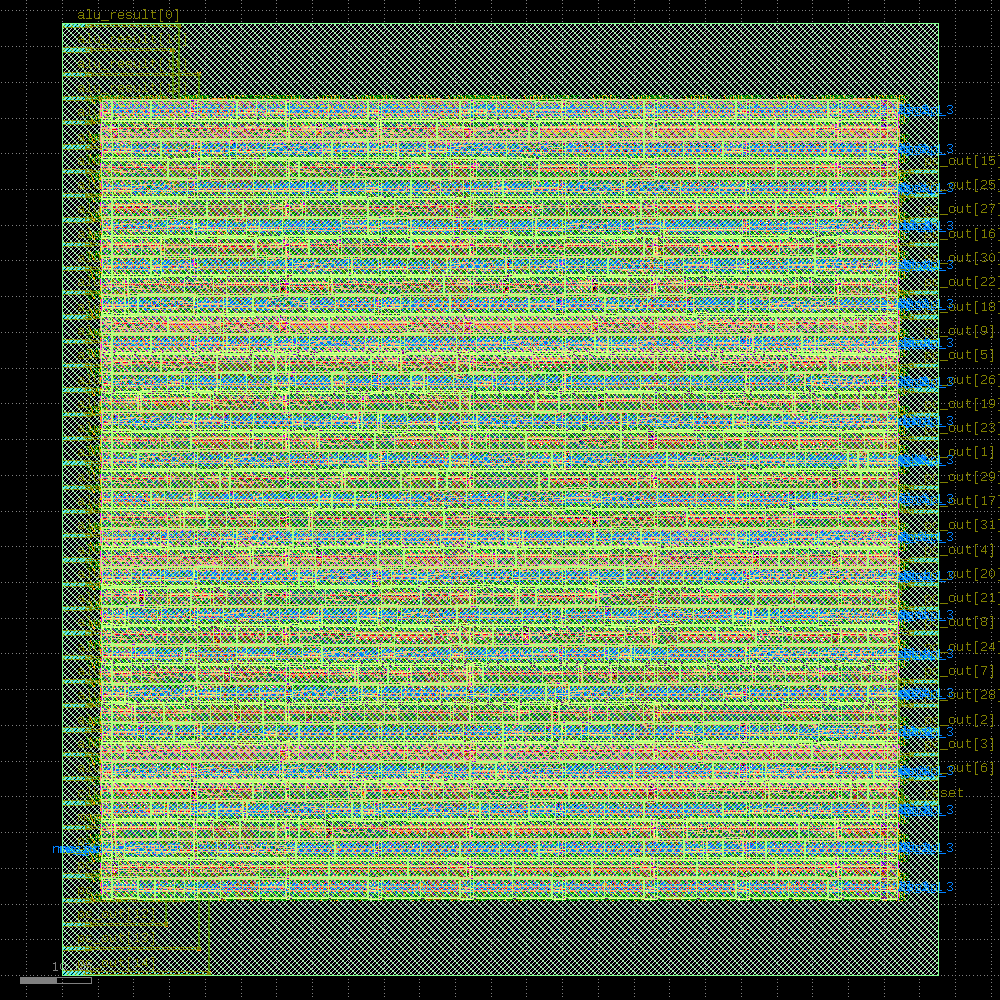

In [38]:
display(gds)

### Design Rule Checks (DRC)

DRC determines that the final layout does not violate any of the rules set by
the foundry to ensure the design is actually manufacturable- for example,
not enough space between two wires, *too much* space between tap cells, and so
on.

A design not passing DRC will typically be rejected by the foundry, who
also run DRC on their side.

In [39]:
DRC = Step.factory.get("Magic.DRC")

drc = DRC(state_in=gds.state_out)
drc.start()

─────────────────────────────────────────────── Design Rule Checks ────────────────────────────────────────────────

[04:23:16] VERBOSE  Running 'Magic.DRC'…                                                               ]8;id=725839;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=774664;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:23:16] VERBOSE  Logging subprocess to ]8;id=145700;file:///content/openlane_run/16-magic-drc/magic-drc.log\openlane_run/]8;;\]8;id=512692;file:///content/openlane_run/16-magic-drc/magic-drc.log\16]8;;\]8;id=145700;file:///content/openlane_run/16-magic-drc/magic-drc.log\-magic-drc/magic-drc.log]8;;\…                     ]8;id=7426;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=863542;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\

Magic 8.3 revision 483 - Compiled on Sun Jun  2 18:57:41 UTC 2024.

Starting magic under Tcl interpreter

...

[INFO] Should be divided by 3 or 4

[INFO] DRC Checking DONE (/content/openlane_run/16-magic-drc/reports/drc_violations.magic.rpt)

[INFO] Saving mag view with DRC errors (/content/openlane_run/16-magic-drc/views/riscv_core.drc.mag)

[INFO] Saved

{'nl': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.nl.v'), 'pnl': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.pnl.v'), 'pnl-sdf-friendly': None, 'pnl-npc': None, 'def': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.def'), 'lef': None, 'openroad-lef': None, 'odb': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.odb'), 'sdc': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.sdc'), 'sdf': {'nom_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/riscv_core__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/riscv_core__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/riscv_core__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/min_tt_025C_1v80/riscv_core__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/min_ss_100C_1v60/riscv_core__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/riscv_core__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/max_tt_025C_1v80/riscv_core__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/max_ss_100C_1v60/riscv_core__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/riscv_core__max_ff_n40C_1v95.sdf')}, 'spef': {'nom_*': Path('/content/openlane_run/13-openroad-rcx/nom/riscv_core.nom.spef'), 'min_*': Path('/content/openlane_run/13-openroad-rcx/min/riscv_core.min.spef'), 'max_*': Path('/content/openlane_run/13-openroad-rcx/max/riscv_core.max.spef')}, 'lib': {'nom_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/riscv_core__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/riscv_core__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/riscv_core__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/min_tt_025C_1v80/riscv_core__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/min_ss_100C_1v60/riscv_core__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/riscv_core__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/max_tt_025C_1v80/riscv_core__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/max_ss_100C_1v60/riscv_core__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/riscv_core__max_ff_n40C_1v95.lib')}, 'spice': None, 'mag': None, 'gds': Path('/content/openlane_run/15-klayout-streamout/riscv_core.gds'), 'mag_gds': None, 'klayout_gds': Path('/content/openlane_run/15-klayout-streamout/riscv_core.klayout.gds'), 'json_h': None, 'vh': None, 'metrics': {'design__instance__count': 736, 'design__instance__area': Decimal('6882.85'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 122.57 133.29', 'design__core__bbox': '5.52 10.88 116.84 122.4', 'flow__warnings__count': 1, 'flow__errors__count': 0, 'design__io': 69, 'design__die__area': Decimal('16337.4'), 'design__core__area': Decimal('12414.4'), 'design__instance__count__stdcell': 736, 'design__instance__area__stdcell': Decimal('6882.85'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__utilization': Decimal('0.554425'), 'design__instance__utilization__stdcell': Decimal('0.554425'), 'floorplan__design__io': 67, 'design__io__hpwl': 6086590, 'design__power_grid_violat

### SPICE Extraction for Layout vs. Schematic Check

This step tries to reconstruct a SPICE netlist from the GDSII file, so it can
later be used for the **Layout vs. Schematic** (LVS) check.

In [40]:
SpiceExtraction = Step.factory.get("Magic.SpiceExtraction")

spx = SpiceExtraction(state_in=drc.state_out)
spx.start()

───────────────────────────────────────────── SPICE Model Extraction ──────────────────────────────────────────────

[04:23:26] VERBOSE  Running 'Magic.SpiceExtraction'…                                                   ]8;id=295455;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=967641;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:23:26] VERBOSE  Logging subprocess to                                                              ]8;id=950847;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=87703;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\
                    ]8;id=148461;file:///content/openlane_run/17-magic-spiceextraction/magic-spiceextraction.log\openlane_run/]8;;\]8;id=736458;file:///content/openlane_run/17-magic-spiceextraction/magic-spiceextraction.log\17]8;;\]8;id=148461;file:///content/openlane_run/17-magic-spiceextraction/magic-spiceextraction.log\-magic-spiceextraction/magic-spiceextraction.log]8;;\…                               

Magic 8.3 revision 483 - Compiled on Sun Jun  2 18:57:41 UTC 2024.

Starting magic under Tcl interpreter

...

Extracting sky130_fd_sc_hd__and4_2 into sky130_fd_sc_hd__and4_2.ext:

Extracting riscv_core into riscv_core.ext:

exttospice finished.

Using technology "sky130A", version 1.0.466-0-gbdc9412

{'nl': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.nl.v'), 'pnl': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.pnl.v'), 'pnl-sdf-friendly': None, 'pnl-npc': None, 'def': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.def'), 'lef': None, 'openroad-lef': None, 'odb': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.odb'), 'sdc': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.sdc'), 'sdf': {'nom_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/riscv_core__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/riscv_core__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/riscv_core__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/min_tt_025C_1v80/riscv_core__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/min_ss_100C_1v60/riscv_core__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/riscv_core__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/max_tt_025C_1v80/riscv_core__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/max_ss_100C_1v60/riscv_core__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/riscv_core__max_ff_n40C_1v95.sdf')}, 'spef': {'nom_*': Path('/content/openlane_run/13-openroad-rcx/nom/riscv_core.nom.spef'), 'min_*': Path('/content/openlane_run/13-openroad-rcx/min/riscv_core.min.spef'), 'max_*': Path('/content/openlane_run/13-openroad-rcx/max/riscv_core.max.spef')}, 'lib': {'nom_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/riscv_core__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/riscv_core__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/riscv_core__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/min_tt_025C_1v80/riscv_core__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/min_ss_100C_1v60/riscv_core__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/riscv_core__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/max_tt_025C_1v80/riscv_core__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/max_ss_100C_1v60/riscv_core__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/riscv_core__max_ff_n40C_1v95.lib')}, 'spice': Path('/content/openlane_run/17-magic-spiceextraction/riscv_core.spice'), 'mag': None, 'gds': Path('/content/openlane_run/15-klayout-streamout/riscv_core.gds'), 'mag_gds': None, 'klayout_gds': Path('/content/openlane_run/15-klayout-streamout/riscv_core.klayout.gds'), 'json_h': None, 'vh': None, 'metrics': {'design__instance__count': 736, 'design__instance__area': Decimal('6882.85'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 122.57 133.29', 'design__core__bbox': '5.52 10.88 116.84 122.4', 'flow__warnings__count': 1, 'flow__errors__count': 0, 'design__io': 69, 'design__die__area': Decimal('16337.4'), 'design__core__area': Decimal('12414.4'), 'design__instance__count__stdcell': 736, 'design__instance__area__stdcell': Decimal('6882.85'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__utilization': Decimal('0.554425'), 'design__instance__utilization__stdcell': Decimal('0.554425'), 'floorplan__desig

### Layout vs. Schematic (LVS)

A comparison between the final Verilog netlist (from PnR) and the final
SPICE netlist (extracted.)

This check effectively compares the physically implemented circuit to the final
Verilog netlist output by OpenROAD.

The idea is, if there are any disconnects, shorts or other mismatches in the
physical implementation that do not exist in the logical view of the design,
they would be caught at this step.

Common issues that result in LVS violations include:
* Lack of fill cells or tap cells in the design
* Two unrelated signals to be shorted, or a wire to be disconnected (most
  commonly seen with misconfigured PDN)

Chips with LVS errors are typically dead on arrival.

In [41]:
LVS = Step.factory.get("Netgen.LVS")

lvs = LVS(state_in=spx.state_out)
lvs.start()

─────────────────────────────────────────────────── Netgen LVS ────────────────────────────────────────────────────

[04:23:39] VERBOSE  Running 'Netgen.LVS'…                                                              ]8;id=314746;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=592130;file:///content/openlane_ipynb/openlane/steps/step.py#1088\1088]8;;\

[04:23:39] VERBOSE  Logging subprocess to ]8;id=403768;file:///content/openlane_run/18-netgen-lvs/netgen-lvs.log\openlane_run/]8;;\]8;id=908299;file:///content/openlane_run/18-netgen-lvs/netgen-lvs.log\18]8;;\]8;id=403768;file:///content/openlane_run/18-netgen-lvs/netgen-lvs.log\-netgen-lvs/netgen-lvs.log]8;;\…                   ]8;id=109671;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=196218;file:///content/openlane_ipynb/openlane/steps/step.py#1268\1268]8;;\

Netgen 1.5.270 compiled on Sun Jun  2 19:00:27 UTC 2024

Warning: netgen command 'format' use fully-qualified name '::netgen::format'

...

Circuits match uniquely.

.

Logging to file "/content/openlane_run/18-netgen-lvs/reports/lvs.netgen.rpt" disabled

LVS Done.

{'nl': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.nl.v'), 'pnl': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.pnl.v'), 'pnl-sdf-friendly': None, 'pnl-npc': None, 'def': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.def'), 'lef': None, 'openroad-lef': None, 'odb': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.odb'), 'sdc': Path('/content/openlane_run/12-openroad-fillinsertion/riscv_core.sdc'), 'sdf': {'nom_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/riscv_core__nom_tt_025C_1v80.sdf'), 'nom_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/riscv_core__nom_ss_100C_1v60.sdf'), 'nom_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/riscv_core__nom_ff_n40C_1v95.sdf'), 'min_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/min_tt_025C_1v80/riscv_core__min_tt_025C_1v80.sdf'), 'min_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/min_ss_100C_1v60/riscv_core__min_ss_100C_1v60.sdf'), 'min_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/riscv_core__min_ff_n40C_1v95.sdf'), 'max_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/max_tt_025C_1v80/riscv_core__max_tt_025C_1v80.sdf'), 'max_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/max_ss_100C_1v60/riscv_core__max_ss_100C_1v60.sdf'), 'max_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/riscv_core__max_ff_n40C_1v95.sdf')}, 'spef': {'nom_*': Path('/content/openlane_run/13-openroad-rcx/nom/riscv_core.nom.spef'), 'min_*': Path('/content/openlane_run/13-openroad-rcx/min/riscv_core.min.spef'), 'max_*': Path('/content/openlane_run/13-openroad-rcx/max/riscv_core.max.spef')}, 'lib': {'nom_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/nom_tt_025C_1v80/riscv_core__nom_tt_025C_1v80.lib'), 'nom_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ss_100C_1v60/riscv_core__nom_ss_100C_1v60.lib'), 'nom_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/nom_ff_n40C_1v95/riscv_core__nom_ff_n40C_1v95.lib'), 'min_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/min_tt_025C_1v80/riscv_core__min_tt_025C_1v80.lib'), 'min_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/min_ss_100C_1v60/riscv_core__min_ss_100C_1v60.lib'), 'min_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/min_ff_n40C_1v95/riscv_core__min_ff_n40C_1v95.lib'), 'max_tt_025C_1v80': Path('/content/openlane_run/14-openroad-stapostpnr/max_tt_025C_1v80/riscv_core__max_tt_025C_1v80.lib'), 'max_ss_100C_1v60': Path('/content/openlane_run/14-openroad-stapostpnr/max_ss_100C_1v60/riscv_core__max_ss_100C_1v60.lib'), 'max_ff_n40C_1v95': Path('/content/openlane_run/14-openroad-stapostpnr/max_ff_n40C_1v95/riscv_core__max_ff_n40C_1v95.lib')}, 'spice': Path('/content/openlane_run/17-magic-spiceextraction/riscv_core.spice'), 'mag': None, 'gds': Path('/content/openlane_run/15-klayout-streamout/riscv_core.gds'), 'mag_gds': None, 'klayout_gds': Path('/content/openlane_run/15-klayout-streamout/riscv_core.klayout.gds'), 'json_h': None, 'vh': None, 'metrics': {'design__instance__count': 736, 'design__instance__area': Decimal('6882.85'), 'design__instance_unmapped__count': 0, 'synthesis__check_error__count': 0, 'design__die__bbox': '0.0 0.0 122.57 133.29', 'design__core__bbox': '5.52 10.88 116.84 122.4', 'flow__warnings__count': 1, 'flow__errors__count': 0, 'design__io': 69, 'design__die__area': Decimal('16337.4'), 'design__core__area': Decimal('12414.4'), 'design__instance__count__stdcell': 736, 'design__instance__area__stdcell': Decimal('6882.85'), 'design__instance__count__macros': 0, 'design__instance__area__macros': 0, 'design__instance__utilization': Decimal('0.554425'), 'design__instance__utilization__stdcell': Decimal('0.554425'), 'floorplan__desig